# Projet Go — Apprentissage par Réseau de Neurones

## Objectif
L'objectif est d'entraîner un réseau de neurones à prédire deux quantités depuis un état de jeu de Go (plateau 19×19) :
- **Policy** : distribution de probabilité sur les 361 coups possibles.
- **Value** : probabilité de victoire du joueur courant (scalaire dans [0, 1]).

Le dataset contient des millions d'états issus de parties réelles. Comme il est impossible de tout charger en RAM, on procède par **streaming** : à chaque epoch, `golois.getBatch()` charge N nouveaux états dans des buffers NumPy.

### Paramètres principaux
| Paramètre | Description |
|-----------|-------------|
| `PLANES`  | Nombre de canaux d'entrée (31 : pierres, libertés, historique, couleur…) |
| `MOVES`   | Taille du vecteur policy (19×19 = 361) |
| `N`       | Nombre d'états chargés par epoch |
| `BATCH`   | Taille de mini-batch pour `model.fit()` |
| `EPOCHS`  | Nombre total d'epochs d'entraînement |


## 1. Installation et imports

In [ ]:
!wget -q https://www.lamsade.dauphine.fr/~cazenave/project2026.zip
!unzip -o -q project2026.zip
!ls -lh games.data golois*.so

-rw-r--r-- 1 root root 518M Oct  7  2022 games.data
-rwxr-xr-x 1 root root 278K Oct  1 15:09 golois.cpython-312-x86_64-linux-gnu.so


In [ ]:
import gc
import datetime
import numpy as np
import tensorflow as tf
import tensorflow.keras as keras
import matplotlib.pyplot as plt
from tensorflow.keras import layers, regularizers, Input, Model

print("TensorFlow version:", tf.__version__)
print("GPU disponible :", tf.config.list_physical_devices('GPU'))

import golois

TensorFlow version: 2.19.0
GPU disponible : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Fonctions utilitaires

### `init_buffers(N, planes, moves)`
Alloue les tableaux NumPy que **golois** remplira à chaque batch.

### `appliquer_symetrie(input_data, policy, k_rot, flip)`
Applique **une** symétrie au batch (rotation + flip optionnel) sans copie mémoire inutile.  
Les 8 symétries sont appliquées **séquentiellement**, ce qui maintient l'empreinte RAM constante (= 1×N états en mémoire, jamais 8×N).

### `entrainement_reseau(model, ..., augmentation=True)`
Boucle d'entraînement. Avec `augmentation=True`, chaque epoch fait 8 passes sur le batch (une par symétrie) — même résultat qu'un dataset ×8, sans exploser la RAM.

### `plot_resultat(history_total, history_validation)`
Courbes train/validation pour chaque métrique.


In [ ]:
# Initialisation des buffers

def init_buffers(N=10000, planes=31, moves=361):
    """Alloue les buffers NumPy utilisés par golois.getBatch / getValidation."""
    input_data = np.random.randint(2, size=(N, 19, 19, planes)).astype('float32')
    policy     = keras.utils.to_categorical(np.random.randint(moves, size=(N,))).astype('float32')
    value      = np.random.randint(2, size=(N,)).astype('float32')
    end        = np.random.randint(2, size=(N, 19, 19, 2)).astype('float32')
    groups     = np.zeros((N, 19, 19, 1), dtype='float32')
    golois.getValidation(input_data, policy, value, end)
    print(f"Buffers initialisés — N={N}, planes={planes}")
    return input_data, policy, value, end, groups


# Data Augmentation

SYMETRIES = [
    (0, False),            # identité
    (1, False),            # 90 degrés
    (2, False),            # 180 degrés
    (3, False),            # 270 degrés
    (0, True),             # flip
    (1, True),             # 90 degrés + flip
    (2, True),             # 180 degrés + flip
    (3, True),             # 270 degrés + flip
]

def appliquer_symetrie(input_data, policy, k_rot, flip):
    """Applique UNE symétrie sans copie mémoire inutile."""
    policy_2d = policy.reshape(-1, 19, 19)
    inp = np.rot90(input_data, k=k_rot, axes=(1, 2))
    pol = np.rot90(policy_2d,  k=k_rot, axes=(1, 2))
    if flip:
        inp = np.flip(inp, axis=2)
        pol = np.flip(pol, axis=2)
    return np.ascontiguousarray(inp), np.ascontiguousarray(pol).reshape(-1, 361)


# Stockage global des résultats

RESULTATS = {}   # { "NomModele_aug" : {"train_acc": [...], "val_acc": [...], "best_val": float} }


# Boucle d'entraînement

def entrainement_reseau(model, epochs, batch_size, input_data, policy, value,
                        N, end, groups, val_every=5, name_network="model",
                        augmentation=True):
    """
    Entraîne model par streaming golois.
    Applique les 8 symétries D4 séquentiellement si augmentation=True
    (empreinte RAM constante = 1×N).
    Stocke les résultats dans RESULTATS[name_network].
    """
    history_total      = []
    history_validation = []
    best_val_acc       = 0.0
    symetries = SYMETRIES if augmentation else [(0, False)]

    for i in range(1, epochs + 1):
        print(f"Epoch {i}/{epochs}")
        golois.getBatch(input_data, policy, value, end, groups, i * N)

        epoch_hist = None
        for k_rot, flip in symetries:
            inp_sym, pol_sym = appliquer_symetrie(input_data, policy, k_rot, flip)
            h = model.fit(inp_sym, [pol_sym, value],
                          epochs=1, batch_size=batch_size, verbose=0)
            epoch_hist = h

        if epoch_hist:
            metrics_str = "  ".join(f"{k}: {v[0]:.4f}" for k, v in epoch_hist.history.items())
            print(f"  {metrics_str}")
            history_total.append(epoch_hist.history)

        if i % val_every == 0:
            golois.getValidation(input_data, policy, value, end)
            print("-- Validation --")
            val = model.evaluate(input_data, [policy, value],
                                 verbose=1, batch_size=batch_size, return_dict=True)
            history_validation.append(val)
            if val["policy_accuracy"] > best_val_acc:
                best_val_acc = val["policy_accuracy"]
                model.save(f"{name_network}.h5")
                print(f"  Meilleur modèle sauvegardé ({best_val_acc*100:.2f}%)")

    # Stocker dans RESULTATS
    train_acc = [h.get("policy_accuracy", [None])[0] for h in history_total]
    val_acc   = [v.get("policy_accuracy", None) for v in history_validation]
    RESULTATS[name_network] = {
        "train_acc":  train_acc,
        "val_acc":    val_acc,
        "best_val":   best_val_acc,
        "val_every":  val_every,
        "augmentation": augmentation,
    }

    plot_courbes(history_total, history_validation, val_every=val_every, title=name_network)
    return best_val_acc

def plot_courbes(history_total, history_validation, val_every=5, title=""):
    train = {}
    for h in history_total:
        d = h.history if hasattr(h, "history") else h
        for k, v in d.items():
            train.setdefault(k, []).append(v[-1])

    epochs_axis = np.arange(1, len(next(iter(train.values()))) + 1)
    val_epochs  = np.array([(j + 1) * val_every for j in range(len(history_validation))])

    val_pol_acc  = [v.get("policy_accuracy", np.nan) for v in history_validation]
    val_pol_loss = [v.get("policy_loss",     np.nan) for v in history_validation]
    val_val_loss = [v.get("value_loss",      np.nan) for v in history_validation]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    # Graphe 1 : Policy Accuracy
    ax = axes[0]
    ax.plot(epochs_axis, train.get("policy_accuracy", []), label="Train", color='steelblue', lw=2)
    if val_pol_acc and any(~np.isnan(val_pol_acc)):
        ax.plot(val_epochs, val_pol_acc, 'o--', label="Validation", color='tomato', lw=2)
    ax.set_title("Policy Accuracy")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Graphe 2 : Policy Loss
    ax = axes[1]
    ax.plot(epochs_axis, train.get("policy_loss", []), label="Train", color='steelblue', lw=2)
    if val_pol_loss and any(~np.isnan(val_pol_loss)):
        ax.plot(val_epochs, val_pol_loss, 'o--', label="Validation", color='tomato', lw=2)
    ax.set_title("Policy Loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Graphe 3 : Value Loss
    ax = axes[2]
    ax.plot(epochs_axis, train.get("value_loss", []), label="Train", color='mediumseagreen', lw=2)
    if val_val_loss and any(~np.isnan(val_val_loss)):
        ax.plot(val_epochs, val_val_loss, 's--', label="Validation", color='darkorange', lw=2)
    ax.set_title("Value Loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Graphe en barres par architecture

def plot_barres_architecture(noms, label=""):
    """
    Affiche un graphe en barres comparant policy_accuracy (val) pour une liste de runs.
    noms : liste de clés présentes dans RESULTATS.
    """
    vals  = [RESULTATS[n]["best_val"] * 100 for n in noms if n in RESULTATS]
    noms_ = [n for n in noms if n in RESULTATS]

    colors = ['steelblue' if not RESULTATS[n]["augmentation"] else 'tomato' for n in noms_]

    fig, ax = plt.subplots(figsize=(7, 4))
    bars = ax.bar(noms_, vals, color=colors, edgecolor='white', linewidth=1.2, width=0.5)
    ax.bar_label(bars, fmt='%.1f%%', padding=4, fontsize=10)
    ax.set_ylim(0, max(vals) * 1.2 if vals else 1)
    ax.set_ylabel("Best policy accuracy (validation) %")
    ax.set_title(label)
    ax.tick_params(axis='x', rotation=15)
    ax.grid(axis='y', alpha=0.3)
    # Légende manuelle
    from matplotlib.patches import Patch
    legend = [Patch(facecolor='steelblue', label='Sans augmentation'),
              Patch(facecolor='tomato',    label='Avec augmentation')]
    ax.legend(handles=legend)
    plt.tight_layout()
    plt.show()


# Résumé final

def plot_resume_final():
    """
    Graphe récapitulatif : toutes les architectures, avec et sans augmentation,
    groupées par architecture.
    """
    archs    = ["CNN Baseline", "Multi-échelles", "DenseNet", "ResNet"]
    keys_aug = ["baseline_cnn_aug", "multiscale_aug", "densenet_aug", "resnet_aug"]
    keys_san = ["baseline_cnn_san", "multiscale_san", "densenet_san", "resnet_san"]

    acc_aug = [RESULTATS.get(k, {}).get("best_val", 0) * 100 for k in keys_aug]
    acc_san = [RESULTATS.get(k, {}).get("best_val", 0) * 100 for k in keys_san]

    x      = np.arange(len(archs))
    width  = 0.35

    fig, ax = plt.subplots(figsize=(10, 5))
    b1 = ax.bar(x - width/2, acc_san, width, label='Sans augmentation',
                color='steelblue', edgecolor='white', linewidth=1.2)
    b2 = ax.bar(x + width/2, acc_aug, width, label='Avec augmentation (×8)',
                color='tomato',    edgecolor='white', linewidth=1.2)

    ax.bar_label(b1, fmt='%.1f%%', padding=4, fontsize=9)
    ax.bar_label(b2, fmt='%.1f%%', padding=4, fontsize=9)

    ax.set_xticks(x)
    ax.set_xticklabels(archs, fontsize=11)
    ax.set_ylabel("Best policy accuracy (validation) %", fontsize=11)
    ax.set_title("Comparaison finale — Architectures × Augmentation", fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(0, max(acc_aug + acc_san + [1]) * 1.2)

    plt.tight_layout()
    plt.show()
    print("\n-- Meilleur modèle -----------------------------------------------")
    tous = {**{k: RESULTATS[k]["best_val"] for k in keys_aug if k in RESULTATS},
            **{k: RESULTATS[k]["best_val"] for k in keys_san if k in RESULTATS}}
    if tous:
        best = max(tous, key=tous.get)
        print(f"  {best} → {tous[best]*100:.2f}%")


## 4. Architectures testées

Toutes les architectures partagent la même interface : entrée `(19, 19, 31)`, deux têtes **policy** et **value** et un nombre de paramètres infèrieur à 100 000.

---

### 4.1 — CNN Baseline (`first_model`)

Architecture de référence : simple empilement de convolutions 3×3.

```
┌──────────────────────────┐
│  Input                   │  (19×19×31)
└────────────┬─────────────┘
             │
┌────────────▼─────────────┐
│  Conv2D 1×1, 32 filtres  │  → (19×19×32)
│  ReLU                    │
└────────────┬─────────────┘
             │
┌────────────▼─────────────┐
│  Conv2D 3×3, 32 filtres  │  → (19×19×32)
│  ReLU          × 5       │
└──────────┬──┬────────────┘
           │  │
  ┌────────▼┐ └▼────────────┐
  │ Conv 1×1│  │  Conv 1×1  │
  │ Flatten │  │  Flatten   │
  │ Softmax │  │  Dense 50  │
  │         │  │  Dense 1   │
  │ POLICY  │  │   VALUE    │
  │ (361)   │  │    (1)     │
  └─────────┘  └────────────┘
```


In [ ]:
def first_model(weight_value=1.0, weight_policy=1.0, lambda_L2=1e-4, planes=31):
    """
    Baseline CNN : Conv1x1 + 5× Conv3x3 ReLU.
    Architecture de référence.
    """
    inp = keras.Input(shape=(19, 19, planes), name='board')

    x = layers.Conv2D(32, 1, activation='relu', padding='same')(inp)
    for _ in range(5):
        x = layers.Conv2D(32, 3, activation='relu', padding='same')(x)

    # Policy head
    p = layers.Conv2D(1, 1, activation='relu', padding='same',
                      use_bias=False, kernel_regularizer=regularizers.l2(lambda_L2))(x)
    p = layers.Flatten()(p)
    p = layers.Activation('softmax', name='policy')(p)

    # Value head
    v = layers.Conv2D(1, 1, activation='relu', padding='same',
                      use_bias=False, kernel_regularizer=regularizers.l2(lambda_L2))(x)
    v = layers.Flatten()(v)
    v = layers.Dense(50, activation='relu', kernel_regularizer=regularizers.l2(lambda_L2))(v)
    v = layers.Dense(1, activation='sigmoid', name='value',
                     kernel_regularizer=regularizers.l2(lambda_L2))(v)

    model = keras.Model(inputs=inp, outputs=[p, v])
    model.compile(
        optimizer=keras.optimizers.Adam(1e-4),
        loss={'policy': 'categorical_crossentropy', 'value': 'mse'},
        loss_weights={'policy': weight_policy, 'value': weight_value},
        metrics={'policy': ['accuracy'], 'value': ['mae']}
    )
    model.summary()
    return model


### 4.2 — Multi-échelles parallèles (`second_model`)

Inspiré d'**Inception** : 7 branches parallèles capturent des patterns à différentes échelles.  
Les grands kernels (≥ 7) utilisent des `SeparableConv2D` pour économiser les paramètres.

In [ ]:
def second_model(weight_value=1.0, weight_policy=1.0, lambda_L2=1e-4, planes=31):
    """
    Multi-échelles parallèles (style Inception).
    Branches 1x1, 3x3, 5x5 (Conv2D) + 7x7, 9x9, 12x12, 15x15 (SeparableConv2D).
    """
    inp = keras.Input(shape=(19, 19, planes), name='board')

    def branche(filters, kernel_size):
        if kernel_size <= 5:
            return layers.Conv2D(filters, kernel_size, activation='swish', padding='same',
                                 kernel_regularizer=regularizers.l2(lambda_L2))(inp)
        else:
            return layers.SeparableConv2D(filters, kernel_size, padding='same', activation='swish',
                                          depthwise_regularizer=regularizers.l2(lambda_L2),
                                          pointwise_regularizer=regularizers.l2(lambda_L2))(inp)

    branches = [
        branche(48,  1),
        branche(24,  3),
        branche(12,  5),
        branche(48,  7),
        branche(24,  9),
        branche(12, 12),
        branche( 6, 15),
    ]

    x = layers.Concatenate()(branches)
    x = layers.Conv2D(64, 1, padding='same', activation='swish',
                      kernel_regularizer=regularizers.l2(lambda_L2))(x)
    x = layers.Conv2D(32, 3, padding='same', activation='swish',
                      kernel_regularizer=regularizers.l2(lambda_L2))(x)
    x = layers.Conv2D(32, 3, padding='same', activation='swish',
                      kernel_regularizer=regularizers.l2(lambda_L2))(x)

    # Policy head
    p = layers.Conv2D(1, 1, padding='same', kernel_regularizer=regularizers.l2(lambda_L2))(x)
    p = layers.Flatten()(p)
    p = layers.Activation('softmax', name='policy')(p)

    # Value head
    v = layers.Conv2D(1, 1, activation='swish', padding='same',
                      kernel_regularizer=regularizers.l2(lambda_L2))(x)
    v = layers.Flatten()(v)
    v = layers.Dense(10, activation='swish', kernel_regularizer=regularizers.l2(lambda_L2))(v)
    v = layers.Dense(1, activation='sigmoid', name='value',
                     kernel_regularizer=regularizers.l2(lambda_L2))(v)

    model = keras.Model(inputs=inp, outputs=[p, v])
    model.compile(
        optimizer=keras.optimizers.Adam(1e-4),
        loss={'policy': 'categorical_crossentropy', 'value': 'mse'},
        loss_weights={'policy': weight_policy, 'value': weight_value},
        metrics={'policy': ['accuracy'], 'value': ['mae']}
    )
    model.summary()
    return model


### 4.3 — Bottleneck DenseNet (`bottleneck_densenet`)

Chaque bloc reçoit la **somme de toutes les sorties précédentes** (connexions denses).  
Structure interne : Conv1×1 (expand) → DepthwiseConv3×3 → Conv1×1 (squeeze).

In [ ]:
def bottleneck_densenet(planes=31, expand=64, squeeze=32, n_blocks=4,
                        lambda_L2=1e-3, weight_value=1.0, weight_policy=1.0):
    """
    Bottleneck DenseNet : blocs (BN -> Conv1x1 -> BN -> DWConv3x3 -> BN -> Conv1x1) avec skip accumulatif.
    (expand=64, squeeze=32, n_blocks=4).
    """
    inp = keras.Input(shape=(19, 19, planes), name='board')

    def dense_block(x, skip_list):
        m = layers.Conv2D(expand, 1, padding='same', use_bias=False,
                          kernel_regularizer=regularizers.l2(lambda_L2))(x)
        m = layers.BatchNormalization()(m)
        m = layers.Activation('relu')(m)

        m = layers.DepthwiseConv2D(3, padding='same', use_bias=False,
                                   depthwise_regularizer=regularizers.l2(lambda_L2))(m)
        m = layers.BatchNormalization()(m)
        m = layers.Activation('relu')(m)

        m = layers.Conv2D(squeeze, 1, use_bias=False,
                          kernel_regularizer=regularizers.l2(lambda_L2))(m)
        m = layers.BatchNormalization()(m)
        m = layers.Activation('relu')(m)

        skip_list.append(m)
        return layers.Add()(skip_list)

    x = layers.Conv2D(squeeze, 1, padding='same',
                      kernel_regularizer=regularizers.l2(lambda_L2))(inp)
    x = layers.Activation('relu')(x)

    skip_list = []
    for _ in range(n_blocks):
        x = dense_block(x, skip_list)

    # Policy head
    p = layers.Conv2D(1, 1, padding='same', kernel_regularizer=regularizers.l2(lambda_L2))(x)
    p = layers.Flatten()(p)
    p = layers.Activation('softmax', name='policy')(p)

    # Value head
    v = layers.GlobalAveragePooling2D()(x)
    v = layers.Dense(50, activation='relu', kernel_regularizer=regularizers.l2(lambda_L2))(v)
    v = layers.Dense(1, activation='sigmoid', name='value',
                     kernel_regularizer=regularizers.l2(lambda_L2))(v)

    model = keras.Model(inputs=inp, outputs=[p, v])
    model.compile(
        optimizer=keras.optimizers.Adam(1e-4),
        loss={'policy': 'categorical_crossentropy', 'value': 'mse'},
        loss_weights={'policy': weight_policy, 'value': weight_value},
        metrics={'policy': ['accuracy'], 'value': ['mae']}
    )
    model.summary()
    return model


### 4.4 — ResNet (`resnet_model`)

Blocs résiduels classiques avec **shortcut connection** : le gradient peut circuler  
directement à travers le réseau, évitant la dégradation en profondeur.

In [ ]:
def resnet_model(planes=31, filters=32, n_blocks=3, lambda_L2=1e-4,
                 weight_value=1.0, weight_policy=1.0):
    """
    ResNet avec blocs résiduels (Conv1x1 -> BN -> swish -> Conv3x3 -> BN -> Add).
    """
    def res_block(x, f):
        shortcut = x
        x = layers.Conv2D(f, 1, padding='same', kernel_regularizer=regularizers.l2(lambda_L2))(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('swish')(x)
        x = layers.Conv2D(f, 3, padding='same', kernel_regularizer=regularizers.l2(lambda_L2))(x)
        x = layers.BatchNormalization()(x)
        x = layers.Add()([shortcut, x])
        x = layers.Activation('swish')(x)
        return x

    inp = keras.Input(shape=(19, 19, planes), name='board')

    # Stem : fusion multi-échelle 5×5 + 1×1
    x1 = layers.Conv2D(filters, 5, padding='same', kernel_regularizer=regularizers.l2(lambda_L2))(inp)
    x2 = layers.Conv2D(filters, 1, padding='same', kernel_regularizer=regularizers.l2(lambda_L2))(inp)
    x  = layers.Add()([x1, x2])
    x  = layers.BatchNormalization()(x)
    x  = layers.Activation('swish')(x)

    for _ in range(n_blocks):
        x = res_block(x, filters)

    # Policy head
    p = layers.Conv2D(1, 3, padding='same', kernel_regularizer=regularizers.l2(lambda_L2))(x)
    p = layers.Flatten()(p)
    p = layers.Activation('softmax', name='policy')(p)

    # Value head
    v = layers.GlobalAveragePooling2D()(x)
    v = layers.Dense(32, activation='swish', kernel_regularizer=regularizers.l2(lambda_L2))(v)
    v = layers.Dense(1, activation='sigmoid', name='value')(v)

    model = keras.Model(inputs=inp, outputs=[p, v])
    model.compile(
        optimizer=keras.optimizers.Adam(3e-4),
        loss={'policy': 'categorical_crossentropy', 'value': 'mse'},
        loss_weights={'policy': weight_value, 'value': weight_policy},
        metrics={'policy': ['accuracy'], 'value': ['mae']}
    )
    model.summary()
    return model


## 5. Expériences

Chaque architecture est testée **avec et sans data augmentation**.
Chaque run produit ses courbes train/val directement. Le résumé final compare tout.


In [ ]:
# Hyperparamètres
PLANES     = 31
MOVES      = 361
EPOCHS     = 100   # Nombre d'epochs
BATCH_SIZE = 128   # Taille de mini-batch
N          = 10000 # États chargés par epoch
VAL_EVERY  = 10    # Fréquence de validation (toutes les N epochs)

# Initialisation des buffers
input_data, policy, value, end, groups = init_buffers(N=N, planes=PLANES, moves=MOVES)


Buffers initialisés — N=10000, planes=31


### 5.1 — CNN Baseline


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ board (InputLayer)  │ (None, 19, 19,    │          0 │ -                 │
│                     │ 31)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 19, 19,    │      1,024 │ board[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 19, 19,    │      9,248 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 19, 19,    │      9,248 │ conv2d_1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 19, 19,    │      9,248 │ conv2d_2[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 19, 19,    │      9,248 │ conv2d_3[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 19, 19,    │      9,248 │ conv2d_4[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 19, 19, 1) │         32 │ conv2d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 19, 19, 1) │         32 │ conv2d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 361)       │          0 │ conv2d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 361)       │          0 │ conv2d_6[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 50)        │     18,100 │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ policy (Activation) │ (None, 361)       │          0 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ value (Dense)       │ (None, 1)         │         51 │ dense[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 65,479 (255.78 KB)

 Trainable params: 65,479 (255.78 KB)

 Non-trainable params: 0 (0.00 B)

...

  Meilleur modèle sauvegardé (25.75%)
Epoch 61/100
  loss: 3.4641  policy_accuracy: 0.2513  policy_loss: 3.3386  value_loss: 0.1196  value_mae: 0.2898
Epoch 62/100
  loss: 3.4850  policy_accuracy: 0.2505  policy_loss: 3.3575  value_loss: 0.1188  value_mae: 0.2884
Epoch 63/100
  loss: 3.4379  policy_accuracy: 0.2645  policy_loss: 3.3151  value_loss: 0.1170  value_mae: 0.2855
Epoch 64/100
  loss: 3.4540  policy_accuracy: 0.2541  policy_loss: 3.3278  value_loss: 0.1188  value_mae: 0.2888
Epoch 65/100
  loss: 3.4435  policy_accuracy: 0.2557  policy_loss: 3.3280  value_loss: 0.1198  value_mae: 0.2900
Epoch 66/100
  loss: 3.4404  policy_accuracy: 0.2626  policy_loss: 3.3263  value_loss: 0.1177  value_mae: 0.2873
Epoch 67/100
  loss: 3.4524  policy_accuracy: 0.2578  policy_loss: 3.3285  value_loss: 0.1167  value_mae: 0.2848
Epoch 68/100
  loss: 3.4194  policy_accuracy: 0.2625  policy_loss: 3.3045  value_loss: 0.1173  value_mae: 0.2878
Epoch 69/100
  loss: 3.4432  policy_accuracy: 0.2563  poli

  Meilleur modèle sauvegardé (26.75%)
Epoch 71/100
  loss: 3.4454  policy_accuracy: 0.2596  policy_loss: 3.3263  value_loss: 0.1181  value_mae: 0.2872
Epoch 72/100
  loss: 3.4079  policy_accuracy: 0.2675  policy_loss: 3.2931  value_loss: 0.1181  value_mae: 0.2882
Epoch 73/100
  loss: 3.4007  policy_accuracy: 0.2625  policy_loss: 3.2857  value_loss: 0.1166  value_mae: 0.2851
Epoch 74/100
  loss: 3.3852  policy_accuracy: 0.2687  policy_loss: 3.2709  value_loss: 0.1161  value_mae: 0.2838
Epoch 75/100
  loss: 3.3983  policy_accuracy: 0.2681  policy_loss: 3.2781  value_loss: 0.1166  value_mae: 0.2856
Epoch 76/100
  loss: 3.3892  policy_accuracy: 0.2726  policy_loss: 3.2598  value_loss: 0.1160  value_mae: 0.2852
Epoch 77/100
  loss: 3.4098  policy_accuracy: 0.2590  policy_loss: 3.2849  value_loss: 0.1180  value_mae: 0.2878
Epoch 78/100
  loss: 3.3690  policy_accuracy: 0.2697  policy_loss: 3.2491  value_loss: 0.1192  value_mae: 0.2881
Epoch 79/100
  loss: 3.4205  policy_accuracy: 0.2663  poli

  Meilleur modèle sauvegardé (27.68%)
Epoch 81/100
  loss: 3.3852  policy_accuracy: 0.2672  policy_loss: 3.2629  value_loss: 0.1176  value_mae: 0.2858
Epoch 82/100
  loss: 3.3927  policy_accuracy: 0.2698  policy_loss: 3.2773  value_loss: 0.1178  value_mae: 0.2857
Epoch 83/100
  loss: 3.3836  policy_accuracy: 0.2702  policy_loss: 3.2612  value_loss: 0.1186  value_mae: 0.2887
Epoch 84/100
  loss: 3.3737  policy_accuracy: 0.2652  policy_loss: 3.2520  value_loss: 0.1171  value_mae: 0.2854
Epoch 85/100
  loss: 3.3486  policy_accuracy: 0.2760  policy_loss: 3.2308  value_loss: 0.1170  value_mae: 0.2857
Epoch 86/100
  loss: 3.3630  policy_accuracy: 0.2735  policy_loss: 3.2409  value_loss: 0.1181  value_mae: 0.2879
Epoch 87/100
  loss: 3.3253  policy_accuracy: 0.2759  policy_loss: 3.2028  value_loss: 0.1185  value_mae: 0.2877
Epoch 88/100
  loss: 3.3421  policy_accuracy: 0.2717  policy_loss: 3.2250  value_loss: 0.1189  value_mae: 0.2896
Epoch 89/100
  loss: 3.3833  policy_accuracy: 0.2675  poli

  Meilleur modèle sauvegardé (28.35%)
Epoch 91/100
  loss: 3.3805  policy_accuracy: 0.2760  policy_loss: 3.2621  value_loss: 0.1188  value_mae: 0.2880
Epoch 92/100
  loss: 3.3845  policy_accuracy: 0.2710  policy_loss: 3.2718  value_loss: 0.1176  value_mae: 0.2870
Epoch 93/100
  loss: 3.3231  policy_accuracy: 0.2827  policy_loss: 3.2044  value_loss: 0.1179  value_mae: 0.2876
Epoch 94/100
  loss: 3.3575  policy_accuracy: 0.2763  policy_loss: 3.2338  value_loss: 0.1193  value_mae: 0.2886
Epoch 95/100
  loss: 3.3409  policy_accuracy: 0.2727  policy_loss: 3.2194  value_loss: 0.1177  value_mae: 0.2866
Epoch 96/100
  loss: 3.3305  policy_accuracy: 0.2807  policy_loss: 3.2126  value_loss: 0.1175  value_mae: 0.2870
Epoch 97/100
  loss: 3.3085  policy_accuracy: 0.2817  policy_loss: 3.1887  value_loss: 0.1186  value_mae: 0.2878
Epoch 98/100
  loss: 3.3396  policy_accuracy: 0.2803  policy_loss: 3.2182  value_loss: 0.1193  value_mae: 0.2893
Epoch 99/100
  loss: 3.3110  policy_accuracy: 0.2781  poli

  Meilleur modèle sauvegardé (28.39%)


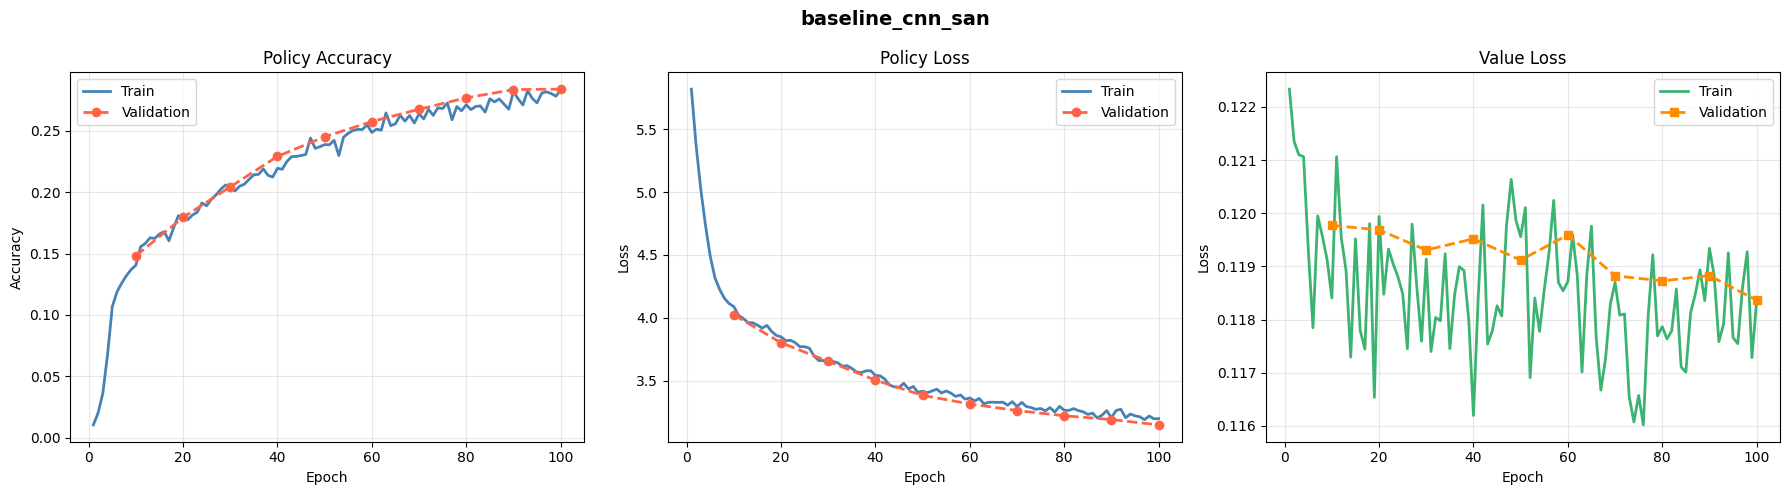

0.2838999927043915

In [ ]:
# CNN Baseline - SANS augmentation
model = first_model()
entrainement_reseau(
    model, EPOCHS, BATCH_SIZE,
    input_data, policy, value, N, end, groups,
    val_every=VAL_EVERY, name_network="baseline_cnn_san",
    augmentation=False
)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ board (InputLayer)  │ (None, 19, 19,    │          0 │ -                 │
│                     │ 31)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 19, 19,    │      1,024 │ board[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 19, 19,    │      9,248 │ conv2d_8[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 19, 19,    │      9,248 │ conv2d_9[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 19, 19,    │      9,248 │ conv2d_10[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 19, 19,    │      9,248 │ conv2d_11[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 19, 19,    │      9,248 │ conv2d_12[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 19, 19, 1) │         32 │ conv2d_13[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_14 (Conv2D)  │ (None, 19, 19, 1) │         32 │ conv2d_13[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_3 (Flatten) │ (None, 361)       │          0 │ conv2d_15[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 361)       │          0 │ conv2d_14[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 50)        │     18,100 │ flatten_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ policy (Activation) │ (None, 361)       │          0 │ flatten_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ value (Dense)       │ (None, 1)         │         51 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 65,479 (255.78 KB)

 Trainable params: 65,479 (255.78 KB)

 Non-trainable params: 0 (0.00 B)

...

  Meilleur modèle sauvegardé (33.73%)
Epoch 61/100
  loss: 2.8943  policy_accuracy: 0.3325  policy_loss: 2.7743  value_loss: 0.1176  value_mae: 0.2865
Epoch 62/100
  loss: 2.9100  policy_accuracy: 0.3366  policy_loss: 2.7932  value_loss: 0.1180  value_mae: 0.2864
Epoch 63/100
  loss: 2.8756  policy_accuracy: 0.3402  policy_loss: 2.7549  value_loss: 0.1151  value_mae: 0.2825
Epoch 64/100
  loss: 2.9027  policy_accuracy: 0.3381  policy_loss: 2.7842  value_loss: 0.1176  value_mae: 0.2863
Epoch 65/100
  loss: 2.9023  policy_accuracy: 0.3349  policy_loss: 2.7820  value_loss: 0.1188  value_mae: 0.2882
Epoch 66/100
  loss: 2.8765  policy_accuracy: 0.3412  policy_loss: 2.7555  value_loss: 0.1154  value_mae: 0.2831
Epoch 67/100
  loss: 2.9008  policy_accuracy: 0.3373  policy_loss: 2.7818  value_loss: 0.1154  value_mae: 0.2824
Epoch 68/100
  loss: 2.8796  policy_accuracy: 0.3452  policy_loss: 2.7618  value_loss: 0.1168  value_mae: 0.2853
Epoch 69/100
  loss: 2.8965  policy_accuracy: 0.3418  poli

  Meilleur modèle sauvegardé (34.21%)
Epoch 71/100
  loss: 2.9136  policy_accuracy: 0.3339  policy_loss: 2.7954  value_loss: 0.1178  value_mae: 0.2851
Epoch 72/100
  loss: 2.8773  policy_accuracy: 0.3435  policy_loss: 2.7606  value_loss: 0.1173  value_mae: 0.2858
Epoch 73/100
  loss: 2.8824  policy_accuracy: 0.3399  policy_loss: 2.7662  value_loss: 0.1150  value_mae: 0.2828
Epoch 74/100
  loss: 2.8597  policy_accuracy: 0.3438  policy_loss: 2.7455  value_loss: 0.1147  value_mae: 0.2806
Epoch 75/100
  loss: 2.8732  policy_accuracy: 0.3390  policy_loss: 2.7544  value_loss: 0.1161  value_mae: 0.2833
Epoch 76/100
  loss: 2.8773  policy_accuracy: 0.3432  policy_loss: 2.7653  value_loss: 0.1157  value_mae: 0.2826
Epoch 77/100
  loss: 2.8864  policy_accuracy: 0.3304  policy_loss: 2.7650  value_loss: 0.1172  value_mae: 0.2858
Epoch 78/100
  loss: 2.8450  policy_accuracy: 0.3432  policy_loss: 2.7287  value_loss: 0.1175  value_mae: 0.2858
Epoch 79/100
  loss: 2.9048  policy_accuracy: 0.3434  poli

  Meilleur modèle sauvegardé (34.40%)
Epoch 81/100
  loss: 2.8803  policy_accuracy: 0.3369  policy_loss: 2.7645  value_loss: 0.1162  value_mae: 0.2828
Epoch 82/100
  loss: 2.8899  policy_accuracy: 0.3396  policy_loss: 2.7726  value_loss: 0.1154  value_mae: 0.2818
Epoch 83/100
  loss: 2.8831  policy_accuracy: 0.3351  policy_loss: 2.7752  value_loss: 0.1179  value_mae: 0.2869
Epoch 84/100
  loss: 2.8747  policy_accuracy: 0.3354  policy_loss: 2.7586  value_loss: 0.1166  value_mae: 0.2841
Epoch 85/100
  loss: 2.8424  policy_accuracy: 0.3476  policy_loss: 2.7203  value_loss: 0.1158  value_mae: 0.2834
Epoch 86/100
  loss: 2.8505  policy_accuracy: 0.3499  policy_loss: 2.7296  value_loss: 0.1176  value_mae: 0.2853
Epoch 87/100
  loss: 2.8331  policy_accuracy: 0.3432  policy_loss: 2.7132  value_loss: 0.1177  value_mae: 0.2859
Epoch 88/100
  loss: 2.8395  policy_accuracy: 0.3448  policy_loss: 2.7180  value_loss: 0.1175  value_mae: 0.2875
Epoch 89/100
  loss: 2.8935  policy_accuracy: 0.3378  poli

  Meilleur modèle sauvegardé (34.56%)
Epoch 91/100
  loss: 2.8946  policy_accuracy: 0.3362  policy_loss: 2.7841  value_loss: 0.1178  value_mae: 0.2852
Epoch 92/100
  loss: 2.8830  policy_accuracy: 0.3406  policy_loss: 2.7620  value_loss: 0.1169  value_mae: 0.2850
Epoch 93/100
  loss: 2.8375  policy_accuracy: 0.3488  policy_loss: 2.7187  value_loss: 0.1177  value_mae: 0.2861
Epoch 94/100
  loss: 2.8623  policy_accuracy: 0.3397  policy_loss: 2.7438  value_loss: 0.1178  value_mae: 0.2862
Epoch 95/100
  loss: 2.8568  policy_accuracy: 0.3398  policy_loss: 2.7485  value_loss: 0.1171  value_mae: 0.2848
Epoch 96/100
  loss: 2.8574  policy_accuracy: 0.3400  policy_loss: 2.7317  value_loss: 0.1172  value_mae: 0.2851
Epoch 97/100
  loss: 2.8365  policy_accuracy: 0.3496  policy_loss: 2.7251  value_loss: 0.1178  value_mae: 0.2860
Epoch 98/100
  loss: 2.8594  policy_accuracy: 0.3453  policy_loss: 2.7436  value_loss: 0.1173  value_mae: 0.2867
Epoch 99/100
  loss: 2.8422  policy_accuracy: 0.3508  poli

  Meilleur modèle sauvegardé (35.37%)


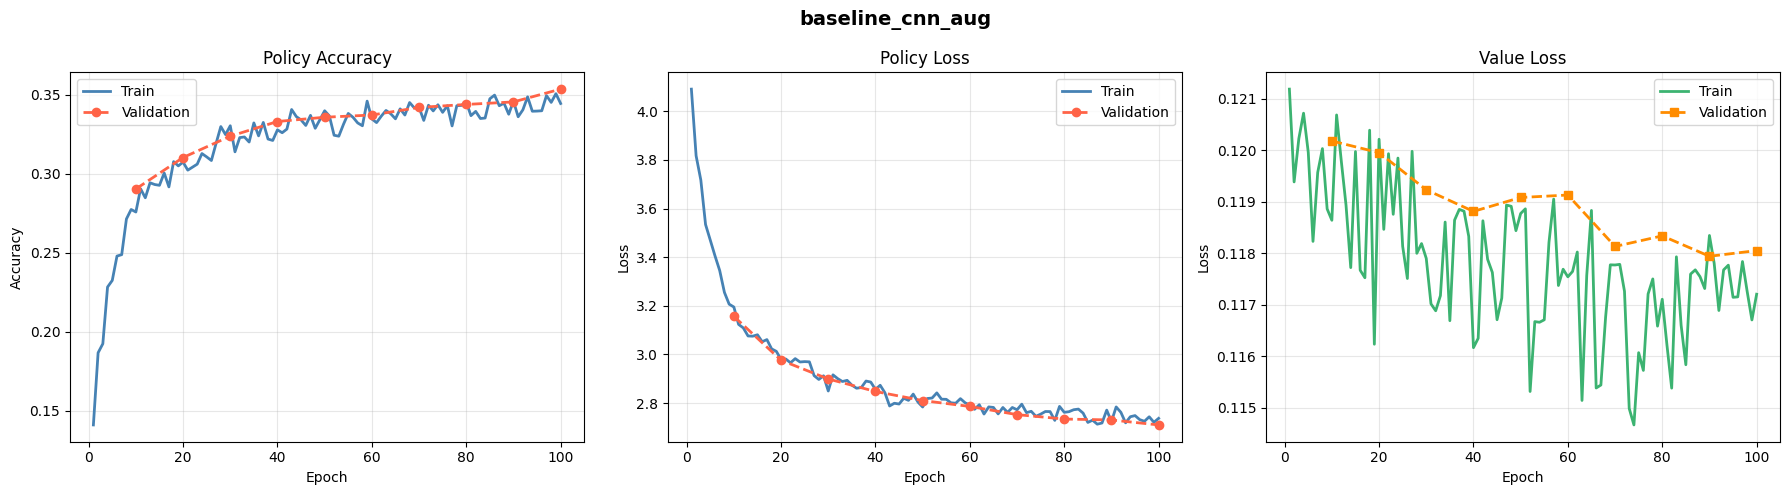

0.35370001196861267

In [ ]:
# CNN Baseline - AVEC augmentation (×8 symétries)
model = first_model()
entrainement_reseau(
    model, EPOCHS, BATCH_SIZE,
    input_data, policy, value, N, end, groups,
    val_every=VAL_EVERY, name_network="baseline_cnn_aug",
    augmentation=True
)


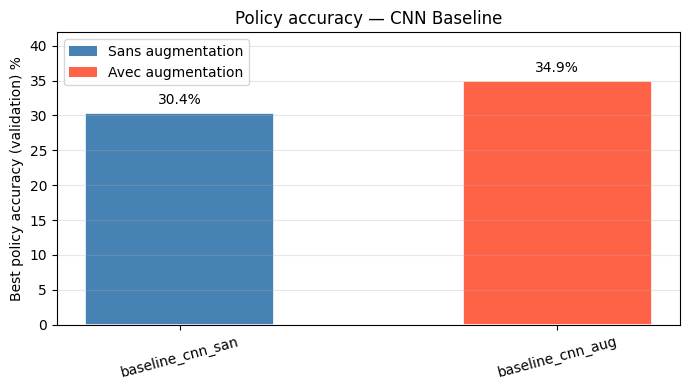

In [ ]:
# Comparaison CNN Baseline
plot_barres_architecture(
    ["baseline_cnn_san", "baseline_cnn_aug"],
    label="Policy accuracy — CNN Baseline"
)


### 5.2 — Multi-échelles


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ board (InputLayer)  │ (None, 19, 19,    │          0 │ -                 │
│                     │ 31)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 19, 19,    │      1,536 │ board[0][0]       │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 19, 19,    │      6,720 │ board[0][0]       │
│                     │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_18 (Conv2D)  │ (None, 19, 19,    │      9,312 │ board[0][0]       │
│                     │ 12)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d    │ (None, 19, 19,    │      3,055 │ board[0][0]       │
│ (SeparableConv2D)   │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_1  │ (None, 19, 19,    │      3,279 │ board[0][0]       │
│ (SeparableConv2D)   │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_2  │ (None, 19, 19,    │      4,848 │ board[0][0]       │
│ (SeparableConv2D)   │ 12)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_3  │ (None, 19, 19, 6) │      7,167 │ board[0][0]       │
│ (SeparableConv2D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 19, 19,    │          0 │ conv2d_16[0][0],  │
│ (Concatenate)       │ 174)              │            │ conv2d_17[0][0],  │
│                     │                   │            │ conv2d_18[0][0],  │
│                     │                   │            │ separable_conv2d… │
│                     │                   │            │ separable_conv2d… │
│                     │                   │            │ separable_conv2d… │
│                     │                   │            │ separable_conv2d… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 19, 19,    │     11,200 │ concatenate[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 19, 19,    │     18,464 │ conv2d_19[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 19, 19,    │      9,248 │ conv2d_20[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, 19, 19, 1) │         33 │ conv2d_21[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 19, 19, 1) │         33 │ conv2d_21[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_5 (Flatten) │ (None, 361)       │          0 │ conv2d_23[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_4 (Flatten) │ (None, 361)       │          0 │ conv2d_22[0][0]   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 78,526 (306.74 KB)

 Trainable params: 78,526 (306.74 KB)

 Non-trainable params: 0 (0.00 B)

...

  Meilleur modèle sauvegardé (24.81%)
Epoch 61/100
  loss: 3.5219  policy_accuracy: 0.2424  policy_loss: 3.3638  value_loss: 0.1176  value_mae: 0.2868
Epoch 62/100
  loss: 3.5229  policy_accuracy: 0.2398  policy_loss: 3.3615  value_loss: 0.1175  value_mae: 0.2851
Epoch 63/100
  loss: 3.4914  policy_accuracy: 0.2507  policy_loss: 3.3446  value_loss: 0.1156  value_mae: 0.2831
Epoch 64/100
  loss: 3.5222  policy_accuracy: 0.2416  policy_loss: 3.3607  value_loss: 0.1174  value_mae: 0.2864
Epoch 65/100
  loss: 3.4924  policy_accuracy: 0.2477  policy_loss: 3.3371  value_loss: 0.1183  value_mae: 0.2870
Epoch 66/100
  loss: 3.4892  policy_accuracy: 0.2514  policy_loss: 3.3360  value_loss: 0.1161  value_mae: 0.2827
Epoch 67/100
  loss: 3.4997  policy_accuracy: 0.2544  policy_loss: 3.3450  value_loss: 0.1152  value_mae: 0.2818
Epoch 68/100
  loss: 3.4899  policy_accuracy: 0.2487  policy_loss: 3.3369  value_loss: 0.1175  value_mae: 0.2847
Epoch 69/100
  loss: 3.4978  policy_accuracy: 0.2427  poli

  Meilleur modèle sauvegardé (25.95%)
Epoch 71/100
  loss: 3.5121  policy_accuracy: 0.2488  policy_loss: 3.3517  value_loss: 0.1168  value_mae: 0.2840
Epoch 72/100
  loss: 3.4724  policy_accuracy: 0.2560  policy_loss: 3.3161  value_loss: 0.1182  value_mae: 0.2858
Epoch 73/100
  loss: 3.4561  policy_accuracy: 0.2582  policy_loss: 3.3024  value_loss: 0.1144  value_mae: 0.2818
Epoch 74/100
  loss: 3.4426  policy_accuracy: 0.2610  policy_loss: 3.2904  value_loss: 0.1154  value_mae: 0.2807
Epoch 75/100
  loss: 3.4709  policy_accuracy: 0.2501  policy_loss: 3.3173  value_loss: 0.1167  value_mae: 0.2841
Epoch 76/100
  loss: 3.4542  policy_accuracy: 0.2595  policy_loss: 3.3081  value_loss: 0.1157  value_mae: 0.2832
Epoch 77/100
  loss: 3.4673  policy_accuracy: 0.2493  policy_loss: 3.3130  value_loss: 0.1163  value_mae: 0.2847
Epoch 78/100
  loss: 3.4349  policy_accuracy: 0.2606  policy_loss: 3.2790  value_loss: 0.1175  value_mae: 0.2861
Epoch 79/100
  loss: 3.4795  policy_accuracy: 0.2535  poli

  Meilleur modèle sauvegardé (26.43%)
Epoch 81/100
  loss: 3.4461  policy_accuracy: 0.2531  policy_loss: 3.2994  value_loss: 0.1158  value_mae: 0.2818
Epoch 82/100
  loss: 3.4632  policy_accuracy: 0.2589  policy_loss: 3.3056  value_loss: 0.1163  value_mae: 0.2824
Epoch 83/100
  loss: 3.4526  policy_accuracy: 0.2594  policy_loss: 3.2985  value_loss: 0.1169  value_mae: 0.2854
Epoch 84/100
  loss: 3.4306  policy_accuracy: 0.2579  policy_loss: 3.2809  value_loss: 0.1157  value_mae: 0.2827
Epoch 85/100
  loss: 3.4194  policy_accuracy: 0.2628  policy_loss: 3.2594  value_loss: 0.1162  value_mae: 0.2828
Epoch 86/100
  loss: 3.4223  policy_accuracy: 0.2657  policy_loss: 3.2575  value_loss: 0.1167  value_mae: 0.2850
Epoch 87/100
  loss: 3.3905  policy_accuracy: 0.2654  policy_loss: 3.2263  value_loss: 0.1180  value_mae: 0.2856
Epoch 88/100
  loss: 3.4034  policy_accuracy: 0.2632  policy_loss: 3.2421  value_loss: 0.1179  value_mae: 0.2862
Epoch 89/100
  loss: 3.4524  policy_accuracy: 0.2590  poli

  Meilleur modèle sauvegardé (26.93%)
Epoch 91/100
  loss: 3.4380  policy_accuracy: 0.2591  policy_loss: 3.2764  value_loss: 0.1177  value_mae: 0.2848
Epoch 92/100
  loss: 3.4395  policy_accuracy: 0.2599  policy_loss: 3.2770  value_loss: 0.1169  value_mae: 0.2842
Epoch 93/100
  loss: 3.3828  policy_accuracy: 0.2733  policy_loss: 3.2255  value_loss: 0.1178  value_mae: 0.2851
Epoch 94/100
  loss: 3.4068  policy_accuracy: 0.2703  policy_loss: 3.2449  value_loss: 0.1168  value_mae: 0.2849
Epoch 95/100
  loss: 3.3996  policy_accuracy: 0.2641  policy_loss: 3.2564  value_loss: 0.1165  value_mae: 0.2844
Epoch 96/100
  loss: 3.3928  policy_accuracy: 0.2725  policy_loss: 3.2316  value_loss: 0.1164  value_mae: 0.2844
Epoch 97/100
  loss: 3.3708  policy_accuracy: 0.2767  policy_loss: 3.2169  value_loss: 0.1171  value_mae: 0.2856
Epoch 98/100
  loss: 3.3998  policy_accuracy: 0.2665  policy_loss: 3.2356  value_loss: 0.1189  value_mae: 0.2871
Epoch 99/100
  loss: 3.3798  policy_accuracy: 0.2662  poli

  Meilleur modèle sauvegardé (27.59%)


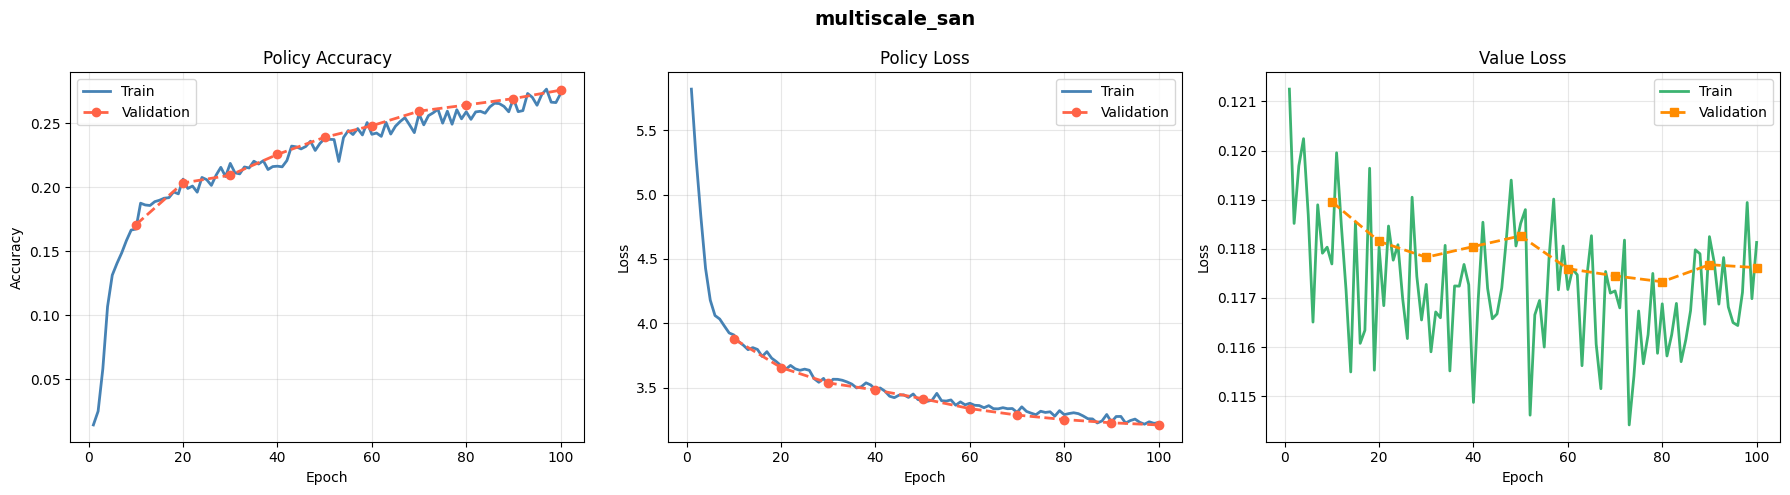

0.2759000062942505

In [ ]:
# Multi-échelles - SANS augmentation
model = second_model()
entrainement_reseau(
    model, EPOCHS, BATCH_SIZE,
    input_data, policy, value, N, end, groups,
    val_every=VAL_EVERY, name_network="multiscale_san",
    augmentation=False
)


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ board (InputLayer)  │ (None, 19, 19,    │          0 │ -                 │
│                     │ 31)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_24 (Conv2D)  │ (None, 19, 19,    │      1,536 │ board[0][0]       │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_25 (Conv2D)  │ (None, 19, 19,    │      6,720 │ board[0][0]       │
│                     │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_26 (Conv2D)  │ (None, 19, 19,    │      9,312 │ board[0][0]       │
│                     │ 12)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_4  │ (None, 19, 19,    │      3,055 │ board[0][0]       │
│ (SeparableConv2D)   │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_5  │ (None, 19, 19,    │      3,279 │ board[0][0]       │
│ (SeparableConv2D)   │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_6  │ (None, 19, 19,    │      4,848 │ board[0][0]       │
│ (SeparableConv2D)   │ 12)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_7  │ (None, 19, 19, 6) │      7,167 │ board[0][0]       │
│ (SeparableConv2D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 19, 19,    │          0 │ conv2d_24[0][0],  │
│ (Concatenate)       │ 174)              │            │ conv2d_25[0][0],  │
│                     │                   │            │ conv2d_26[0][0],  │
│                     │                   │            │ separable_conv2d… │
│                     │                   │            │ separable_conv2d… │
│                     │                   │            │ separable_conv2d… │
│                     │                   │            │ separable_conv2d… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_27 (Conv2D)  │ (None, 19, 19,    │     11,200 │ concatenate_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_28 (Conv2D)  │ (None, 19, 19,    │     18,464 │ conv2d_27[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_29 (Conv2D)  │ (None, 19, 19,    │      9,248 │ conv2d_28[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_31 (Conv2D)  │ (None, 19, 19, 1) │         33 │ conv2d_29[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_30 (Conv2D)  │ (None, 19, 19, 1) │         33 │ conv2d_29[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_7 (Flatten) │ (None, 361)       │          0 │ conv2d_31[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_6 (Flatten) │ (None, 361)       │          0 │ conv2d_30[0][0]   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 78,526 (306.74 KB)

 Trainable params: 78,526 (306.74 KB)

 Non-trainable params: 0 (0.00 B)

...

  Meilleur modèle sauvegardé (32.94%)
Epoch 51/100
  loss: 3.0220  policy_accuracy: 0.3253  policy_loss: 2.8504  value_loss: 0.1168  value_mae: 0.2860
Epoch 52/100
  loss: 3.0280  policy_accuracy: 0.3202  policy_loss: 2.8755  value_loss: 0.1155  value_mae: 0.2812
Epoch 53/100
  loss: 3.0586  policy_accuracy: 0.3160  policy_loss: 2.9021  value_loss: 0.1162  value_mae: 0.2820
Epoch 54/100
  loss: 3.0175  policy_accuracy: 0.3271  policy_loss: 2.8574  value_loss: 0.1159  value_mae: 0.2823
Epoch 55/100
  loss: 3.0280  policy_accuracy: 0.3286  policy_loss: 2.8702  value_loss: 0.1155  value_mae: 0.2823
Epoch 56/100
  loss: 3.0183  policy_accuracy: 0.3241  policy_loss: 2.8584  value_loss: 0.1168  value_mae: 0.2846
Epoch 57/100
  loss: 2.9958  policy_accuracy: 0.3312  policy_loss: 2.8323  value_loss: 0.1188  value_mae: 0.2873
Epoch 58/100
  loss: 3.0129  policy_accuracy: 0.3264  policy_loss: 2.8503  value_loss: 0.1170  value_mae: 0.2842
Epoch 59/100
  loss: 2.9909  policy_accuracy: 0.3364  poli

  Meilleur modèle sauvegardé (33.63%)
Epoch 61/100
  loss: 2.9725  policy_accuracy: 0.3302  policy_loss: 2.8199  value_loss: 0.1168  value_mae: 0.2850
Epoch 62/100
  loss: 2.9957  policy_accuracy: 0.3270  policy_loss: 2.8341  value_loss: 0.1166  value_mae: 0.2847
Epoch 63/100
  loss: 2.9633  policy_accuracy: 0.3327  policy_loss: 2.8077  value_loss: 0.1145  value_mae: 0.2802
Epoch 64/100
  loss: 2.9854  policy_accuracy: 0.3283  policy_loss: 2.8260  value_loss: 0.1168  value_mae: 0.2841
Epoch 65/100
  loss: 2.9690  policy_accuracy: 0.3290  policy_loss: 2.8042  value_loss: 0.1175  value_mae: 0.2860
Epoch 66/100
  loss: 2.9660  policy_accuracy: 0.3334  policy_loss: 2.8063  value_loss: 0.1145  value_mae: 0.2810
Epoch 67/100
  loss: 2.9733  policy_accuracy: 0.3318  policy_loss: 2.8198  value_loss: 0.1148  value_mae: 0.2799
Epoch 68/100
  loss: 2.9668  policy_accuracy: 0.3398  policy_loss: 2.8001  value_loss: 0.1165  value_mae: 0.2831
Epoch 69/100
  loss: 2.9805  policy_accuracy: 0.3309  poli

  Meilleur modèle sauvegardé (34.08%)
Epoch 81/100
  loss: 2.9411  policy_accuracy: 0.3347  policy_loss: 2.7811  value_loss: 0.1150  value_mae: 0.2808
Epoch 82/100
  loss: 2.9622  policy_accuracy: 0.3332  policy_loss: 2.8008  value_loss: 0.1153  value_mae: 0.2807
Epoch 83/100
  loss: 2.9521  policy_accuracy: 0.3327  policy_loss: 2.7894  value_loss: 0.1157  value_mae: 0.2843
Epoch 84/100
  loss: 2.9347  policy_accuracy: 0.3402  policy_loss: 2.7656  value_loss: 0.1156  value_mae: 0.2818
Epoch 85/100
  loss: 2.9178  policy_accuracy: 0.3414  policy_loss: 2.7640  value_loss: 0.1157  value_mae: 0.2819
Epoch 86/100
  loss: 2.9229  policy_accuracy: 0.3452  policy_loss: 2.7636  value_loss: 0.1165  value_mae: 0.2836
Epoch 87/100
  loss: 2.9002  policy_accuracy: 0.3434  policy_loss: 2.7395  value_loss: 0.1164  value_mae: 0.2837
Epoch 88/100
  loss: 2.9124  policy_accuracy: 0.3411  policy_loss: 2.7429  value_loss: 0.1173  value_mae: 0.2854
Epoch 89/100
  loss: 2.9626  policy_accuracy: 0.3369  poli

  Meilleur modèle sauvegardé (34.25%)
Epoch 91/100
  loss: 2.9601  policy_accuracy: 0.3327  policy_loss: 2.8013  value_loss: 0.1171  value_mae: 0.2838
Epoch 92/100
  loss: 2.9529  policy_accuracy: 0.3296  policy_loss: 2.7953  value_loss: 0.1156  value_mae: 0.2831
Epoch 93/100
  loss: 2.8976  policy_accuracy: 0.3443  policy_loss: 2.7397  value_loss: 0.1166  value_mae: 0.2840
Epoch 94/100
  loss: 2.9217  policy_accuracy: 0.3348  policy_loss: 2.7587  value_loss: 0.1167  value_mae: 0.2841
Epoch 95/100
  loss: 2.9156  policy_accuracy: 0.3366  policy_loss: 2.7504  value_loss: 0.1164  value_mae: 0.2835
Epoch 96/100
  loss: 2.9212  policy_accuracy: 0.3421  policy_loss: 2.7559  value_loss: 0.1156  value_mae: 0.2831
Epoch 97/100
  loss: 2.8979  policy_accuracy: 0.3403  policy_loss: 2.7218  value_loss: 0.1168  value_mae: 0.2844
Epoch 98/100
  loss: 2.9226  policy_accuracy: 0.3368  policy_loss: 2.7601  value_loss: 0.1168  value_mae: 0.2859
Epoch 99/100
  loss: 2.9171  policy_accuracy: 0.3395  poli

  Meilleur modèle sauvegardé (34.35%)


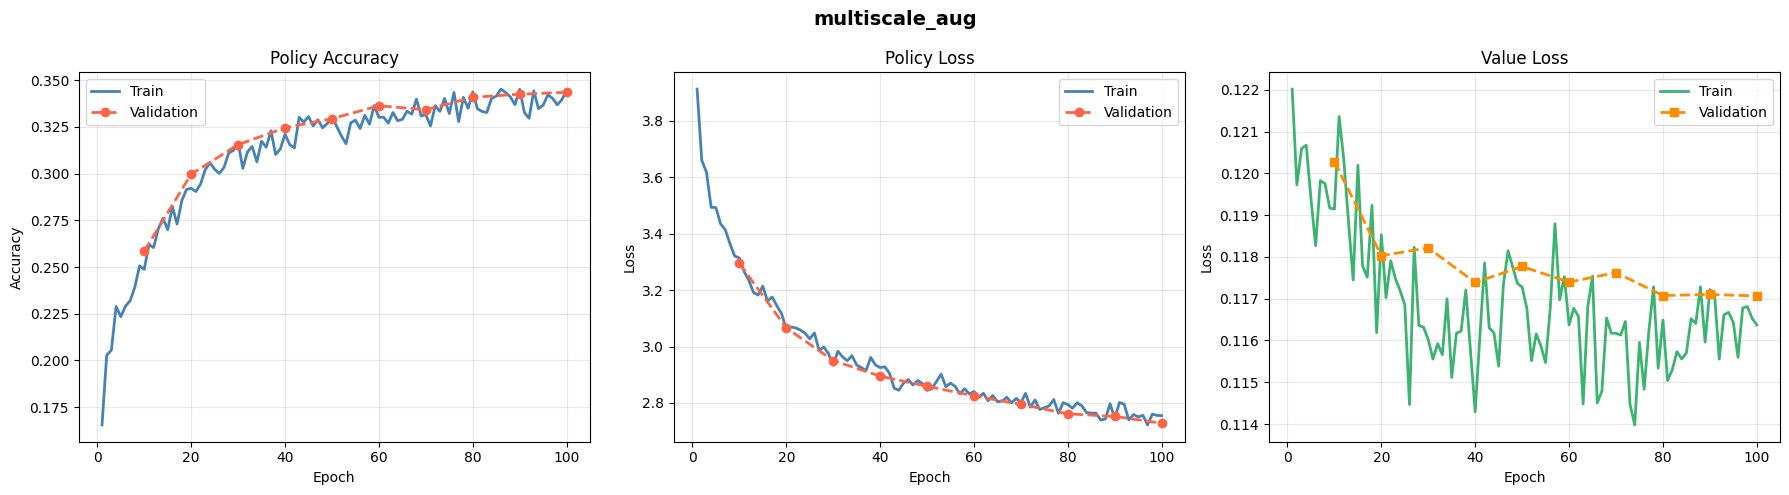

0.3434999883174896

In [ ]:
# Multi-échelles - AVEC augmentation (×8 symétries)
model = second_model()
entrainement_reseau(
    model, EPOCHS, BATCH_SIZE,
    input_data, policy, value, N, end, groups,
    val_every=VAL_EVERY, name_network="multiscale_aug",
    augmentation=True
)


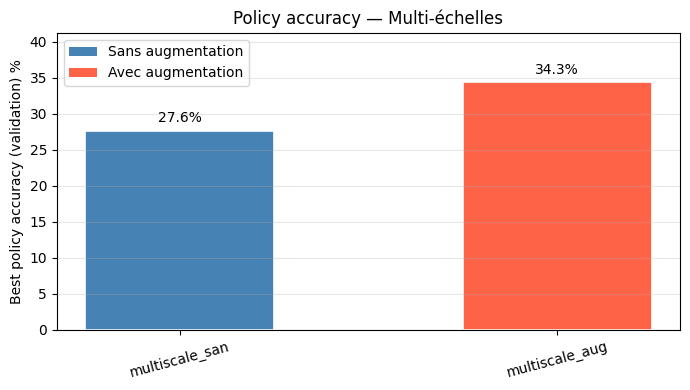

In [ ]:
# Comparaison Multi-échelles
plot_barres_architecture(
    ["multiscale_san", "multiscale_aug"],
    label="Policy accuracy — Multi-échelles"
)


### 5.3 — Bottleneck DenseNet


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ board (InputLayer)  │ (None, 19, 19,    │          0 │ -                 │
│                     │ 31)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_32 (Conv2D)  │ (None, 19, 19,    │      1,024 │ board[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 19, 19,    │          0 │ conv2d_32[0][0]   │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_33 (Conv2D)  │ (None, 19, 19,    │      2,048 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 19, 19,    │        256 │ conv2d_33[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 19, 19,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d    │ (None, 19, 19,    │        576 │ activation_1[0][… │
│ (DepthwiseConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 19, 19,    │        256 │ depthwise_conv2d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 19, 19,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_34 (Conv2D)  │ (None, 19, 19,    │      2,048 │ activation_2[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 19, 19,    │        128 │ conv2d_34[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 19, 19,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 19, 19,    │          0 │ activation_3[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_35 (Conv2D)  │ (None, 19, 19,    │      2,048 │ add[0][0]         │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 19, 19,    │        256 │ conv2d_35[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 19, 19,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d_1  │ (None, 19, 19,    │        576 │ activation_4[0][

 Total params: 24,006 (93.77 KB)

 Trainable params: 22,726 (88.77 KB)

 Non-trainable params: 1,280 (5.00 KB)

...

  Meilleur modèle sauvegardé (25.25%)
Epoch 61/100
  loss: 3.8743  policy_accuracy: 0.2528  policy_loss: 3.4091  value_loss: 0.1181  value_mae: 0.2887
Epoch 62/100
  loss: 3.8786  policy_accuracy: 0.2454  policy_loss: 3.4181  value_loss: 0.1190  value_mae: 0.2881
Epoch 63/100
  loss: 3.8349  policy_accuracy: 0.2545  policy_loss: 3.3750  value_loss: 0.1160  value_mae: 0.2848
Epoch 64/100
  loss: 3.8585  policy_accuracy: 0.2522  policy_loss: 3.3986  value_loss: 0.1183  value_mae: 0.2878
Epoch 65/100
  loss: 3.8240  policy_accuracy: 0.2491  policy_loss: 3.3661  value_loss: 0.1185  value_mae: 0.2887
Epoch 66/100
  loss: 3.8320  policy_accuracy: 0.2571  policy_loss: 3.3733  value_loss: 0.1164  value_mae: 0.2860
Epoch 67/100
  loss: 3.8211  policy_accuracy: 0.2563  policy_loss: 3.3671  value_loss: 0.1167  value_mae: 0.2842
Epoch 68/100
  loss: 3.7886  policy_accuracy: 0.2631  policy_loss: 3.3243  value_loss: 0.1177  value_mae: 0.2877
Epoch 69/100
  loss: 3.8014  policy_accuracy: 0.2606  poli

  Meilleur modèle sauvegardé (26.61%)
Epoch 71/100
  loss: 3.7998  policy_accuracy: 0.2595  policy_loss: 3.3424  value_loss: 0.1176  value_mae: 0.2868
Epoch 72/100
  loss: 3.7440  policy_accuracy: 0.2679  policy_loss: 3.2812  value_loss: 0.1179  value_mae: 0.2871
Epoch 73/100
  loss: 3.7366  policy_accuracy: 0.2719  policy_loss: 3.2841  value_loss: 0.1162  value_mae: 0.2843
Epoch 74/100
  loss: 3.7246  policy_accuracy: 0.2655  policy_loss: 3.2726  value_loss: 0.1149  value_mae: 0.2824
Epoch 75/100
  loss: 3.7298  policy_accuracy: 0.2679  policy_loss: 3.2848  value_loss: 0.1168  value_mae: 0.2855
Epoch 76/100
  loss: 3.7061  policy_accuracy: 0.2777  policy_loss: 3.2494  value_loss: 0.1157  value_mae: 0.2847
Epoch 77/100
  loss: 3.7251  policy_accuracy: 0.2586  policy_loss: 3.2797  value_loss: 0.1174  value_mae: 0.2872
Epoch 78/100
  loss: 3.6766  policy_accuracy: 0.2728  policy_loss: 3.2297  value_loss: 0.1172  value_mae: 0.2873
Epoch 79/100
  loss: 3.7130  policy_accuracy: 0.2717  poli

  Meilleur modèle sauvegardé (27.69%)
Epoch 81/100
  loss: 3.6876  policy_accuracy: 0.2743  policy_loss: 3.2451  value_loss: 0.1165  value_mae: 0.2849
Epoch 82/100
  loss: 3.6970  policy_accuracy: 0.2719  policy_loss: 3.2489  value_loss: 0.1173  value_mae: 0.2851
Epoch 83/100
  loss: 3.6648  policy_accuracy: 0.2726  policy_loss: 3.2227  value_loss: 0.1181  value_mae: 0.2881
Epoch 84/100
  loss: 3.6467  policy_accuracy: 0.2823  policy_loss: 3.2088  value_loss: 0.1166  value_mae: 0.2854
Epoch 85/100
  loss: 3.6277  policy_accuracy: 0.2822  policy_loss: 3.1826  value_loss: 0.1170  value_mae: 0.2855
Epoch 86/100
  loss: 3.6192  policy_accuracy: 0.2829  policy_loss: 3.1816  value_loss: 0.1182  value_mae: 0.2880
Epoch 87/100
  loss: 3.6005  policy_accuracy: 0.2808  policy_loss: 3.1597  value_loss: 0.1180  value_mae: 0.2881
Epoch 88/100
  loss: 3.6201  policy_accuracy: 0.2775  policy_loss: 3.1859  value_loss: 0.1191  value_mae: 0.2896
Epoch 89/100
  loss: 3.6522  policy_accuracy: 0.2768  poli

  Meilleur modèle sauvegardé (28.68%)
Epoch 91/100
  loss: 3.6370  policy_accuracy: 0.2781  policy_loss: 3.2094  value_loss: 0.1182  value_mae: 0.2879
Epoch 92/100
  loss: 3.6443  policy_accuracy: 0.2701  policy_loss: 3.2146  value_loss: 0.1176  value_mae: 0.2869
Epoch 93/100
  loss: 3.5655  policy_accuracy: 0.2879  policy_loss: 3.1208  value_loss: 0.1183  value_mae: 0.2880
Epoch 94/100
  loss: 3.5974  policy_accuracy: 0.2866  policy_loss: 3.1552  value_loss: 0.1185  value_mae: 0.2886
Epoch 95/100
  loss: 3.5775  policy_accuracy: 0.2873  policy_loss: 3.1438  value_loss: 0.1177  value_mae: 0.2870
Epoch 96/100
  loss: 3.5793  policy_accuracy: 0.2896  policy_loss: 3.1516  value_loss: 0.1176  value_mae: 0.2866
Epoch 97/100
  loss: 3.5516  policy_accuracy: 0.2956  policy_loss: 3.1182  value_loss: 0.1184  value_mae: 0.2877
Epoch 98/100
  loss: 3.5714  policy_accuracy: 0.2873  policy_loss: 3.1349  value_loss: 0.1183  value_mae: 0.2886
Epoch 99/100
  loss: 3.5432  policy_accuracy: 0.2886  poli

  Meilleur modèle sauvegardé (29.24%)


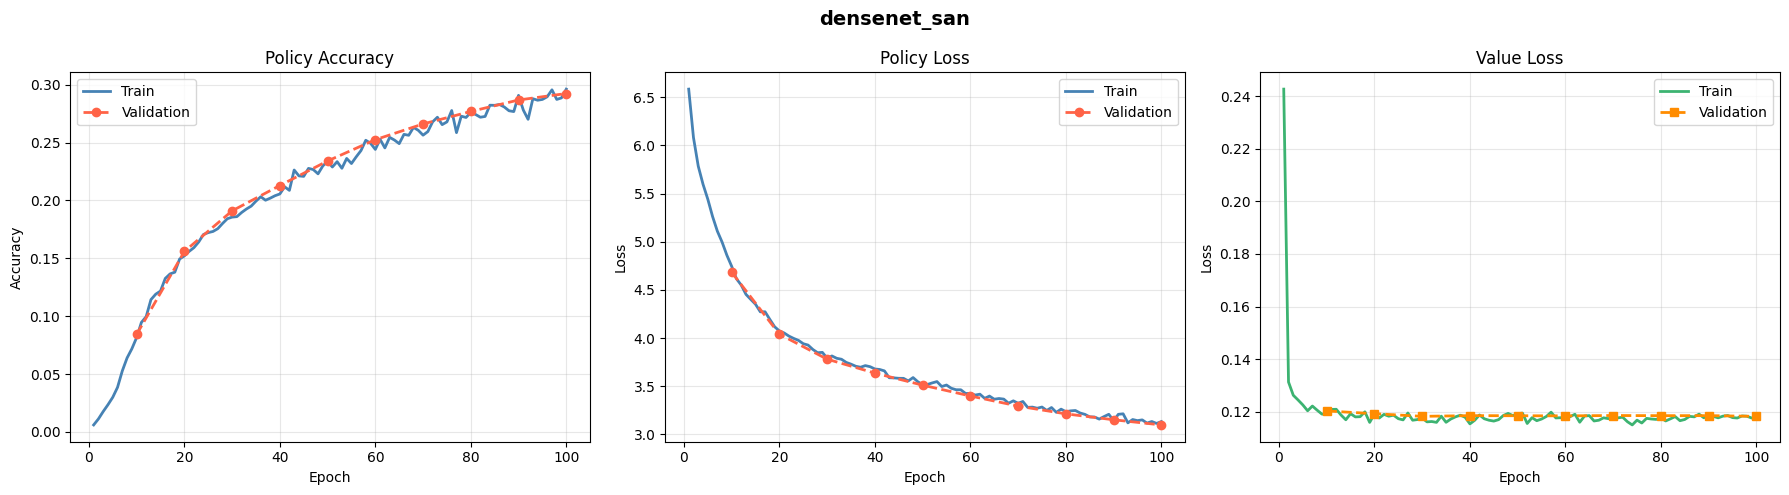

0.2924000024795532

In [ ]:
# Bottleneck DenseNet - SANS augmentation
model = bottleneck_densenet(expand=64, squeeze=32, n_blocks=4)
entrainement_reseau(
    model, EPOCHS, BATCH_SIZE,
    input_data, policy, value, N, end, groups,
    val_every=VAL_EVERY, name_network="densenet_san",
    augmentation=False
)


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ board (InputLayer)  │ (None, 19, 19,    │          0 │ -                 │
│                     │ 31)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_42 (Conv2D)  │ (None, 19, 19,    │      1,024 │ board[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_13       │ (None, 19, 19,    │          0 │ conv2d_42[0][0]   │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_43 (Conv2D)  │ (None, 19, 19,    │      2,048 │ activation_13[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 19, 19,    │        256 │ conv2d_43[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_14       │ (None, 19, 19,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d_4  │ (None, 19, 19,    │        576 │ activation_14[0]… │
│ (DepthwiseConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 19, 19,    │        256 │ depthwise_conv2d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_15       │ (None, 19, 19,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_44 (Conv2D)  │ (None, 19, 19,    │      2,048 │ activation_15[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 19, 19,    │        128 │ conv2d_44[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_16       │ (None, 19, 19,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 19, 19,    │          0 │ activation_16[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_45 (Conv2D)  │ (None, 19, 19,    │      2,048 │ add_4[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 19, 19,    │        256 │ conv2d_45[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_17       │ (None, 19, 19,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d_5  │ (None, 19, 19,    │        576 │ activation_17[0]

 Total params: 24,006 (93.77 KB)

 Trainable params: 22,726 (88.77 KB)

 Non-trainable params: 1,280 (5.00 KB)

...

  Meilleur modèle sauvegardé (34.93%)
Epoch 51/100
  loss: 2.9799  policy_accuracy: 0.3545  policy_loss: 2.6855  value_loss: 0.1191  value_mae: 0.2900
Epoch 52/100
  loss: 2.9734  policy_accuracy: 0.3504  policy_loss: 2.6910  value_loss: 0.1146  value_mae: 0.2823
Epoch 53/100
  loss: 2.9962  policy_accuracy: 0.3433  policy_loss: 2.7149  value_loss: 0.1171  value_mae: 0.2851
Epoch 54/100
  loss: 2.9569  policy_accuracy: 0.3524  policy_loss: 2.6817  value_loss: 0.1165  value_mae: 0.2841
Epoch 55/100
  loss: 2.9833  policy_accuracy: 0.3527  policy_loss: 2.7129  value_loss: 0.1162  value_mae: 0.2851
Epoch 56/100
  loss: 2.9495  policy_accuracy: 0.3561  policy_loss: 2.6714  value_loss: 0.1175  value_mae: 0.2873
Epoch 57/100
  loss: 2.9360  policy_accuracy: 0.3585  policy_loss: 2.6559  value_loss: 0.1191  value_mae: 0.2899
Epoch 58/100
  loss: 2.9455  policy_accuracy: 0.3543  policy_loss: 2.6664  value_loss: 0.1176  value_mae: 0.2875
Epoch 59/100
  loss: 2.9127  policy_accuracy: 0.3634  poli

  Meilleur modèle sauvegardé (35.54%)
Epoch 61/100
  loss: 2.9118  policy_accuracy: 0.3590  policy_loss: 2.6418  value_loss: 0.1177  value_mae: 0.2880
Epoch 62/100
  loss: 2.9158  policy_accuracy: 0.3608  policy_loss: 2.6574  value_loss: 0.1174  value_mae: 0.2865
Epoch 63/100
  loss: 2.8722  policy_accuracy: 0.3645  policy_loss: 2.6066  value_loss: 0.1157  value_mae: 0.2842
Epoch 64/100
  loss: 2.9155  policy_accuracy: 0.3570  policy_loss: 2.6459  value_loss: 0.1175  value_mae: 0.2867
Epoch 65/100
  loss: 2.9022  policy_accuracy: 0.3555  policy_loss: 2.6346  value_loss: 0.1177  value_mae: 0.2872
Epoch 66/100
  loss: 2.8799  policy_accuracy: 0.3620  policy_loss: 2.6183  value_loss: 0.1152  value_mae: 0.2838
Epoch 67/100
  loss: 2.8886  policy_accuracy: 0.3632  policy_loss: 2.6458  value_loss: 0.1156  value_mae: 0.2824
Epoch 68/100
  loss: 2.8755  policy_accuracy: 0.3613  policy_loss: 2.6137  value_loss: 0.1169  value_mae: 0.2859
Epoch 69/100
  loss: 2.8958  policy_accuracy: 0.3591  poli

  Meilleur modèle sauvegardé (35.98%)
Epoch 71/100
  loss: 2.8955  policy_accuracy: 0.3624  policy_loss: 2.6443  value_loss: 0.1172  value_mae: 0.2848
Epoch 72/100
  loss: 2.8590  policy_accuracy: 0.3689  policy_loss: 2.6103  value_loss: 0.1166  value_mae: 0.2858
Epoch 73/100
  loss: 2.8614  policy_accuracy: 0.3632  policy_loss: 2.6139  value_loss: 0.1147  value_mae: 0.2836
Epoch 74/100
  loss: 2.8386  policy_accuracy: 0.3666  policy_loss: 2.5847  value_loss: 0.1146  value_mae: 0.2817
Epoch 75/100
  loss: 2.8471  policy_accuracy: 0.3660  policy_loss: 2.6004  value_loss: 0.1167  value_mae: 0.2838
Epoch 76/100
  loss: 2.8483  policy_accuracy: 0.3729  policy_loss: 2.6041  value_loss: 0.1150  value_mae: 0.2828
Epoch 77/100
  loss: 2.8638  policy_accuracy: 0.3594  policy_loss: 2.6218  value_loss: 0.1162  value_mae: 0.2847
Epoch 78/100
  loss: 2.8199  policy_accuracy: 0.3700  policy_loss: 2.5675  value_loss: 0.1172  value_mae: 0.2859
Epoch 79/100
  loss: 2.8751  policy_accuracy: 0.3654  poli

  Meilleur modèle sauvegardé (36.59%)
Epoch 81/100
  loss: 2.8370  policy_accuracy: 0.3603  policy_loss: 2.5932  value_loss: 0.1155  value_mae: 0.2835
Epoch 82/100
  loss: 2.8579  policy_accuracy: 0.3571  policy_loss: 2.6202  value_loss: 0.1156  value_mae: 0.2829
Epoch 83/100
  loss: 2.8459  policy_accuracy: 0.3605  policy_loss: 2.5959  value_loss: 0.1169  value_mae: 0.2860
Epoch 84/100
  loss: 2.8352  policy_accuracy: 0.3675  policy_loss: 2.5912  value_loss: 0.1153  value_mae: 0.2829
Epoch 85/100
  loss: 2.7966  policy_accuracy: 0.3695  policy_loss: 2.5542  value_loss: 0.1155  value_mae: 0.2836
Epoch 86/100
  loss: 2.8031  policy_accuracy: 0.3793  policy_loss: 2.5577  value_loss: 0.1170  value_mae: 0.2856
Epoch 87/100
  loss: 2.7872  policy_accuracy: 0.3731  policy_loss: 2.5521  value_loss: 0.1169  value_mae: 0.2858
Epoch 88/100
  loss: 2.7825  policy_accuracy: 0.3737  policy_loss: 2.5464  value_loss: 0.1173  value_mae: 0.2869
Epoch 89/100
  loss: 2.8521  policy_accuracy: 0.3623  poli

  Meilleur modèle sauvegardé (37.08%)


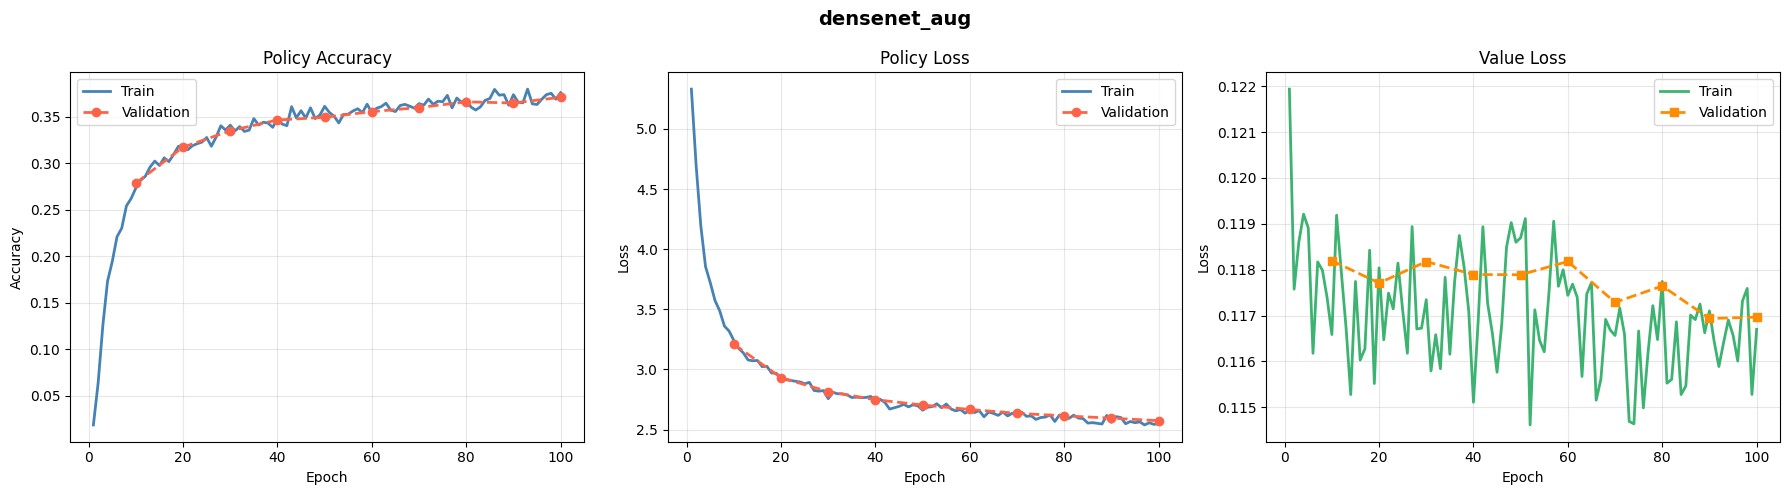

0.3707999885082245

In [ ]:
# Bottleneck DenseNet - AVEC augmentation (×8 symétries)
model = bottleneck_densenet(expand=64, squeeze=32, n_blocks=4)
entrainement_reseau(
    model, EPOCHS, BATCH_SIZE,
    input_data, policy, value, N, end, groups,
    val_every=VAL_EVERY, name_network="densenet_aug",
    augmentation=True
)


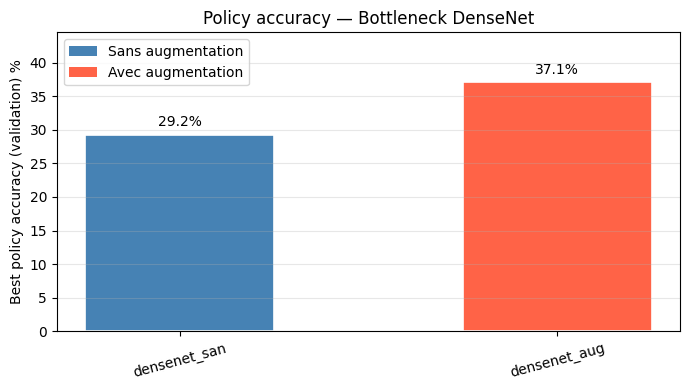

In [ ]:
# Comparaison Bottleneck DenseNet
plot_barres_architecture(
    ["densenet_san", "densenet_aug"],
    label="Policy accuracy — Bottleneck DenseNet"
)


### 5.4 — ResNet


Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ board (InputLayer)  │ (None, 19, 19,    │          0 │ -                 │
│                     │ 31)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_52 (Conv2D)  │ (None, 19, 19,    │     24,832 │ board[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_53 (Conv2D)  │ (None, 19, 19,    │      1,024 │ board[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_8 (Add)         │ (None, 19, 19,    │          0 │ conv2d_52[0][0],  │
│                     │ 32)               │            │ conv2d_53[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 19, 19,    │        128 │ add_8[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_26       │ (None, 19, 19,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_54 (Conv2D)  │ (None, 19, 19,    │      1,056 │ activation_26[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 19, 19,    │        128 │ conv2d_54[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_27       │ (None, 19, 19,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_55 (Conv2D)  │ (None, 19, 19,    │      9,248 │ activation_27[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 19, 19,    │        128 │ conv2d_55[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_9 (Add)         │ (None, 19, 19,    │          0 │ activation_26[0]… │
│                     │ 32)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_28       │ (None, 19, 19,    │          0 │ add_9[0][0]       │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_56 (Conv2D)  │ (None, 19, 19,    │      1,056 │ activation_28[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 19, 19,    │        128 │ conv2d_56[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_29       │ (None, 19, 19,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_57 (Conv2D)  │ (None, 19, 19,    │      9,248 │ activation_29[0]

 Total params: 59,042 (230.63 KB)

 Trainable params: 58,594 (228.88 KB)

 Non-trainable params: 448 (1.75 KB)

...

  Meilleur modèle sauvegardé (33.28%)
Epoch 51/100
  loss: 2.9997  policy_accuracy: 0.3275  policy_loss: 2.8656  value_loss: 0.1193  value_mae: 0.2880
Epoch 52/100
  loss: 3.0079  policy_accuracy: 0.3249  policy_loss: 2.8669  value_loss: 0.1151  value_mae: 0.2824
Epoch 53/100
  loss: 3.0256  policy_accuracy: 0.3167  policy_loss: 2.8772  value_loss: 0.1171  value_mae: 0.2850
Epoch 54/100
  loss: 2.9885  policy_accuracy: 0.3313  policy_loss: 2.8511  value_loss: 0.1164  value_mae: 0.2838
Epoch 55/100
  loss: 3.0168  policy_accuracy: 0.3310  policy_loss: 2.8712  value_loss: 0.1167  value_mae: 0.2843
Epoch 56/100
  loss: 3.0048  policy_accuracy: 0.3317  policy_loss: 2.8642  value_loss: 0.1179  value_mae: 0.2866
Epoch 57/100
  loss: 2.9776  policy_accuracy: 0.3280  policy_loss: 2.8276  value_loss: 0.1193  value_mae: 0.2890
Epoch 58/100
  loss: 2.9855  policy_accuracy: 0.3333  policy_loss: 2.8382  value_loss: 0.1174  value_mae: 0.2866
Epoch 59/100
  loss: 2.9745  policy_accuracy: 0.3419  poli

  Meilleur modèle sauvegardé (33.72%)
Epoch 61/100
  loss: 2.9641  policy_accuracy: 0.3327  policy_loss: 2.8138  value_loss: 0.1173  value_mae: 0.2867
Epoch 62/100
  loss: 2.9743  policy_accuracy: 0.3322  policy_loss: 2.8271  value_loss: 0.1172  value_mae: 0.2860
Epoch 63/100
  loss: 2.9484  policy_accuracy: 0.3343  policy_loss: 2.8064  value_loss: 0.1152  value_mae: 0.2830
Epoch 64/100
  loss: 2.9758  policy_accuracy: 0.3276  policy_loss: 2.8342  value_loss: 0.1169  value_mae: 0.2857
Epoch 65/100
  loss: 2.9750  policy_accuracy: 0.3328  policy_loss: 2.8334  value_loss: 0.1177  value_mae: 0.2878
Epoch 66/100
  loss: 2.9485  policy_accuracy: 0.3419  policy_loss: 2.8050  value_loss: 0.1159  value_mae: 0.2841
Epoch 67/100
  loss: 2.9648  policy_accuracy: 0.3332  policy_loss: 2.8301  value_loss: 0.1152  value_mae: 0.2821
Epoch 68/100
  loss: 2.9531  policy_accuracy: 0.3408  policy_loss: 2.8135  value_loss: 0.1165  value_mae: 0.2854
Epoch 69/100
  loss: 2.9821  policy_accuracy: 0.3344  poli

  Meilleur modèle sauvegardé (33.81%)
Epoch 71/100
  loss: 2.9806  policy_accuracy: 0.3319  policy_loss: 2.8300  value_loss: 0.1175  value_mae: 0.2846
Epoch 72/100
  loss: 2.9398  policy_accuracy: 0.3478  policy_loss: 2.7924  value_loss: 0.1174  value_mae: 0.2861
Epoch 73/100
  loss: 2.9526  policy_accuracy: 0.3386  policy_loss: 2.8086  value_loss: 0.1154  value_mae: 0.2830
Epoch 74/100
  loss: 2.9289  policy_accuracy: 0.3409  policy_loss: 2.7831  value_loss: 0.1146  value_mae: 0.2812
Epoch 75/100
  loss: 2.9356  policy_accuracy: 0.3350  policy_loss: 2.7868  value_loss: 0.1162  value_mae: 0.2832
Epoch 76/100
  loss: 2.9357  policy_accuracy: 0.3472  policy_loss: 2.7874  value_loss: 0.1156  value_mae: 0.2822
Epoch 77/100
  loss: 2.9468  policy_accuracy: 0.3313  policy_loss: 2.8019  value_loss: 0.1169  value_mae: 0.2855
Epoch 78/100
  loss: 2.9121  policy_accuracy: 0.3367  policy_loss: 2.7629  value_loss: 0.1184  value_mae: 0.2863
Epoch 79/100
  loss: 2.9581  policy_accuracy: 0.3364  poli

  Meilleur modèle sauvegardé (34.19%)
Epoch 81/100
  loss: 2.9316  policy_accuracy: 0.3334  policy_loss: 2.7843  value_loss: 0.1161  value_mae: 0.2830
Epoch 82/100
  loss: 2.9594  policy_accuracy: 0.3299  policy_loss: 2.8117  value_loss: 0.1159  value_mae: 0.2826
Epoch 83/100
  loss: 2.9405  policy_accuracy: 0.3319  policy_loss: 2.7955  value_loss: 0.1172  value_mae: 0.2861
Epoch 84/100
  loss: 2.9377  policy_accuracy: 0.3426  policy_loss: 2.7926  value_loss: 0.1160  value_mae: 0.2840
Epoch 85/100
  loss: 2.9107  policy_accuracy: 0.3443  policy_loss: 2.7698  value_loss: 0.1166  value_mae: 0.2838
Epoch 86/100
  loss: 2.9157  policy_accuracy: 0.3477  policy_loss: 2.7711  value_loss: 0.1176  value_mae: 0.2857
Epoch 87/100
  loss: 2.9013  policy_accuracy: 0.3387  policy_loss: 2.7548  value_loss: 0.1179  value_mae: 0.2862
Epoch 88/100
  loss: 2.8905  policy_accuracy: 0.3413  policy_loss: 2.7511  value_loss: 0.1172  value_mae: 0.2867
Epoch 89/100
  loss: 2.9587  policy_accuracy: 0.3318  poli

  Meilleur modèle sauvegardé (34.67%)
Epoch 91/100
  loss: 2.9646  policy_accuracy: 0.3340  policy_loss: 2.8171  value_loss: 0.1176  value_mae: 0.2857
Epoch 92/100
  loss: 2.9466  policy_accuracy: 0.3391  policy_loss: 2.7930  value_loss: 0.1168  value_mae: 0.2846
Epoch 93/100
  loss: 2.8993  policy_accuracy: 0.3504  policy_loss: 2.7514  value_loss: 0.1183  value_mae: 0.2856
Epoch 94/100
  loss: 2.9229  policy_accuracy: 0.3382  policy_loss: 2.7714  value_loss: 0.1181  value_mae: 0.2861
Epoch 95/100
  loss: 2.9185  policy_accuracy: 0.3395  policy_loss: 2.7710  value_loss: 0.1171  value_mae: 0.2853
Epoch 96/100
  loss: 2.9240  policy_accuracy: 0.3378  policy_loss: 2.7806  value_loss: 0.1169  value_mae: 0.2854
Epoch 97/100
  loss: 2.8985  policy_accuracy: 0.3419  policy_loss: 2.7534  value_loss: 0.1180  value_mae: 0.2865
Epoch 98/100
  loss: 2.9226  policy_accuracy: 0.3352  policy_loss: 2.7827  value_loss: 0.1188  value_mae: 0.2872
Epoch 99/100
  loss: 2.9094  policy_accuracy: 0.3381  poli

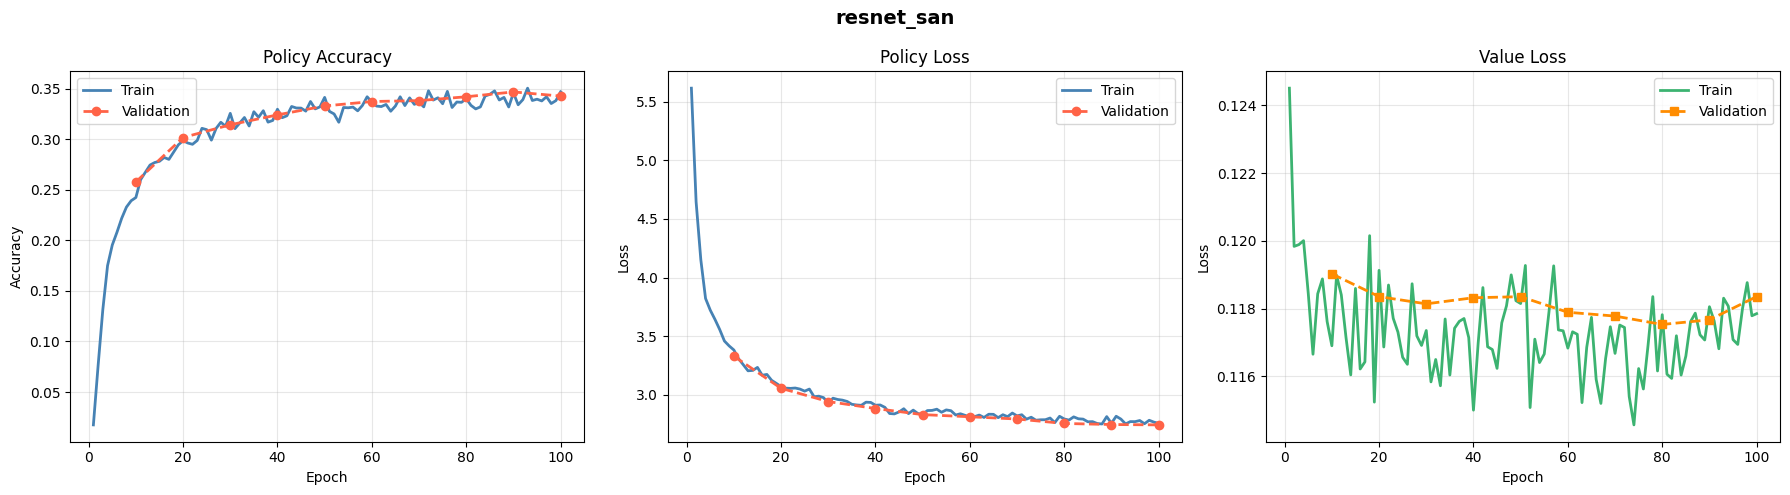

0.3467000126838684

In [ ]:
# ResNet - SANS augmentation
model = resnet_model(filters=32, n_blocks=3)
entrainement_reseau(
    model, EPOCHS, BATCH_SIZE,
    input_data, policy, value, N, end, groups,
    val_every=VAL_EVERY, name_network="resnet_san",
    augmentation=False
)


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ board (InputLayer)  │ (None, 19, 19,    │          0 │ -                 │
│                     │ 31)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_61 (Conv2D)  │ (None, 19, 19,    │     24,832 │ board[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_62 (Conv2D)  │ (None, 19, 19,    │      1,024 │ board[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_12 (Add)        │ (None, 19, 19,    │          0 │ conv2d_61[0][0],  │
│                     │ 32)               │            │ conv2d_62[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 19, 19,    │        128 │ add_12[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_33       │ (None, 19, 19,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_63 (Conv2D)  │ (None, 19, 19,    │      1,056 │ activation_33[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 19, 19,    │        128 │ conv2d_63[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_34       │ (None, 19, 19,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_64 (Conv2D)  │ (None, 19, 19,    │      9,248 │ activation_34[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 19, 19,    │        128 │ conv2d_64[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_13 (Add)        │ (None, 19, 19,    │          0 │ activation_33[0]… │
│                     │ 32)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_35       │ (None, 19, 19,    │          0 │ add_13[0][0]      │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_65 (Conv2D)  │ (None, 19, 19,    │      1,056 │ activation_35[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 19, 19,    │        128 │ conv2d_65[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_36       │ (None, 19, 19,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_66 (Conv2D)  │ (None, 19, 19,    │      9,248 │ activation_36[0]

 Total params: 59,042 (230.63 KB)

 Trainable params: 58,594 (228.88 KB)

 Non-trainable params: 448 (1.75 KB)

...

  Meilleur modèle sauvegardé (36.69%)
Epoch 51/100
  loss: 2.7197  policy_accuracy: 0.3681  policy_loss: 2.5670  value_loss: 0.1186  value_mae: 0.2875
Epoch 52/100
  loss: 2.7039  policy_accuracy: 0.3658  policy_loss: 2.5473  value_loss: 0.1146  value_mae: 0.2809
Epoch 53/100
  loss: 2.7259  policy_accuracy: 0.3597  policy_loss: 2.5757  value_loss: 0.1164  value_mae: 0.2827
Epoch 54/100
  loss: 2.6918  policy_accuracy: 0.3736  policy_loss: 2.5483  value_loss: 0.1158  value_mae: 0.2827
Epoch 55/100
  loss: 2.7058  policy_accuracy: 0.3782  policy_loss: 2.5552  value_loss: 0.1152  value_mae: 0.2825
Epoch 56/100
  loss: 2.6903  policy_accuracy: 0.3760  policy_loss: 2.5363  value_loss: 0.1179  value_mae: 0.2854
Epoch 57/100
  loss: 2.6773  policy_accuracy: 0.3786  policy_loss: 2.5256  value_loss: 0.1179  value_mae: 0.2869
Epoch 58/100
  loss: 2.6954  policy_accuracy: 0.3740  policy_loss: 2.5450  value_loss: 0.1166  value_mae: 0.2844
Epoch 59/100
  loss: 2.6686  policy_accuracy: 0.3861  poli

  Meilleur modèle sauvegardé (36.91%)
Epoch 61/100
  loss: 2.6851  policy_accuracy: 0.3712  policy_loss: 2.5349  value_loss: 0.1179  value_mae: 0.2857
Epoch 62/100
  loss: 2.6833  policy_accuracy: 0.3757  policy_loss: 2.5336  value_loss: 0.1171  value_mae: 0.2849
Epoch 63/100
  loss: 2.6531  policy_accuracy: 0.3743  policy_loss: 2.5060  value_loss: 0.1149  value_mae: 0.2819
Epoch 64/100
  loss: 2.7026  policy_accuracy: 0.3723  policy_loss: 2.5469  value_loss: 0.1178  value_mae: 0.2856
Epoch 65/100
  loss: 2.6868  policy_accuracy: 0.3730  policy_loss: 2.5346  value_loss: 0.1181  value_mae: 0.2868
Epoch 66/100
  loss: 2.6655  policy_accuracy: 0.3801  policy_loss: 2.5179  value_loss: 0.1146  value_mae: 0.2819
Epoch 67/100
  loss: 2.6770  policy_accuracy: 0.3753  policy_loss: 2.5285  value_loss: 0.1149  value_mae: 0.2804
Epoch 68/100
  loss: 2.6718  policy_accuracy: 0.3787  policy_loss: 2.5180  value_loss: 0.1166  value_mae: 0.2842
Epoch 69/100
  loss: 2.6947  policy_accuracy: 0.3771  poli

  Meilleur modèle sauvegardé (37.15%)
Epoch 71/100
  loss: 2.6973  policy_accuracy: 0.3735  policy_loss: 2.5415  value_loss: 0.1163  value_mae: 0.2835
Epoch 72/100
  loss: 2.6615  policy_accuracy: 0.3812  policy_loss: 2.5151  value_loss: 0.1166  value_mae: 0.2843
Epoch 73/100
  loss: 2.6616  policy_accuracy: 0.3785  policy_loss: 2.5086  value_loss: 0.1144  value_mae: 0.2806
Epoch 74/100
  loss: 2.6522  policy_accuracy: 0.3795  policy_loss: 2.5033  value_loss: 0.1145  value_mae: 0.2795
Epoch 75/100
  loss: 2.6543  policy_accuracy: 0.3747  policy_loss: 2.5051  value_loss: 0.1165  value_mae: 0.2827
Epoch 76/100
  loss: 2.6571  policy_accuracy: 0.3855  policy_loss: 2.5088  value_loss: 0.1144  value_mae: 0.2815
Epoch 77/100
  loss: 2.6864  policy_accuracy: 0.3673  policy_loss: 2.5293  value_loss: 0.1164  value_mae: 0.2839
Epoch 78/100
  loss: 2.6245  policy_accuracy: 0.3795  policy_loss: 2.4668  value_loss: 0.1176  value_mae: 0.2852
Epoch 79/100
  loss: 2.6971  policy_accuracy: 0.3739  poli

  Meilleur modèle sauvegardé (37.50%)
Epoch 81/100
  loss: 2.6681  policy_accuracy: 0.3729  policy_loss: 2.5208  value_loss: 0.1155  value_mae: 0.2821
Epoch 82/100
  loss: 2.6929  policy_accuracy: 0.3738  policy_loss: 2.5427  value_loss: 0.1147  value_mae: 0.2806
Epoch 83/100
  loss: 2.6800  policy_accuracy: 0.3703  policy_loss: 2.5227  value_loss: 0.1168  value_mae: 0.2859
Epoch 84/100
  loss: 2.6677  policy_accuracy: 0.3720  policy_loss: 2.5159  value_loss: 0.1155  value_mae: 0.2829
Epoch 85/100
  loss: 2.6354  policy_accuracy: 0.3820  policy_loss: 2.4815  value_loss: 0.1162  value_mae: 0.2830
Epoch 86/100
  loss: 2.6370  policy_accuracy: 0.3850  policy_loss: 2.4750  value_loss: 0.1179  value_mae: 0.2853
Epoch 87/100
  loss: 2.6355  policy_accuracy: 0.3832  policy_loss: 2.4859  value_loss: 0.1170  value_mae: 0.2847
Epoch 88/100
  loss: 2.6293  policy_accuracy: 0.3832  policy_loss: 2.4818  value_loss: 0.1175  value_mae: 0.2858
Epoch 89/100
  loss: 2.6887  policy_accuracy: 0.3739  poli

  Meilleur modèle sauvegardé (37.66%)
Epoch 91/100
  loss: 2.6838  policy_accuracy: 0.3695  policy_loss: 2.5309  value_loss: 0.1166  value_mae: 0.2839
Epoch 92/100
  loss: 2.6747  policy_accuracy: 0.3788  policy_loss: 2.5160  value_loss: 0.1159  value_mae: 0.2835
Epoch 93/100
  loss: 2.6259  policy_accuracy: 0.3841  policy_loss: 2.4701  value_loss: 0.1174  value_mae: 0.2856
Epoch 94/100
  loss: 2.6511  policy_accuracy: 0.3719  policy_loss: 2.5001  value_loss: 0.1174  value_mae: 0.2857
Epoch 95/100
  loss: 2.6614  policy_accuracy: 0.3743  policy_loss: 2.5081  value_loss: 0.1167  value_mae: 0.2832
Epoch 96/100
  loss: 2.6558  policy_accuracy: 0.3786  policy_loss: 2.4978  value_loss: 0.1169  value_mae: 0.2842
Epoch 97/100
  loss: 2.6334  policy_accuracy: 0.3797  policy_loss: 2.4876  value_loss: 0.1175  value_mae: 0.2853
Epoch 98/100
  loss: 2.6673  policy_accuracy: 0.3730  policy_loss: 2.5082  value_loss: 0.1181  value_mae: 0.2864
Epoch 99/100
  loss: 2.6601  policy_accuracy: 0.3787  poli

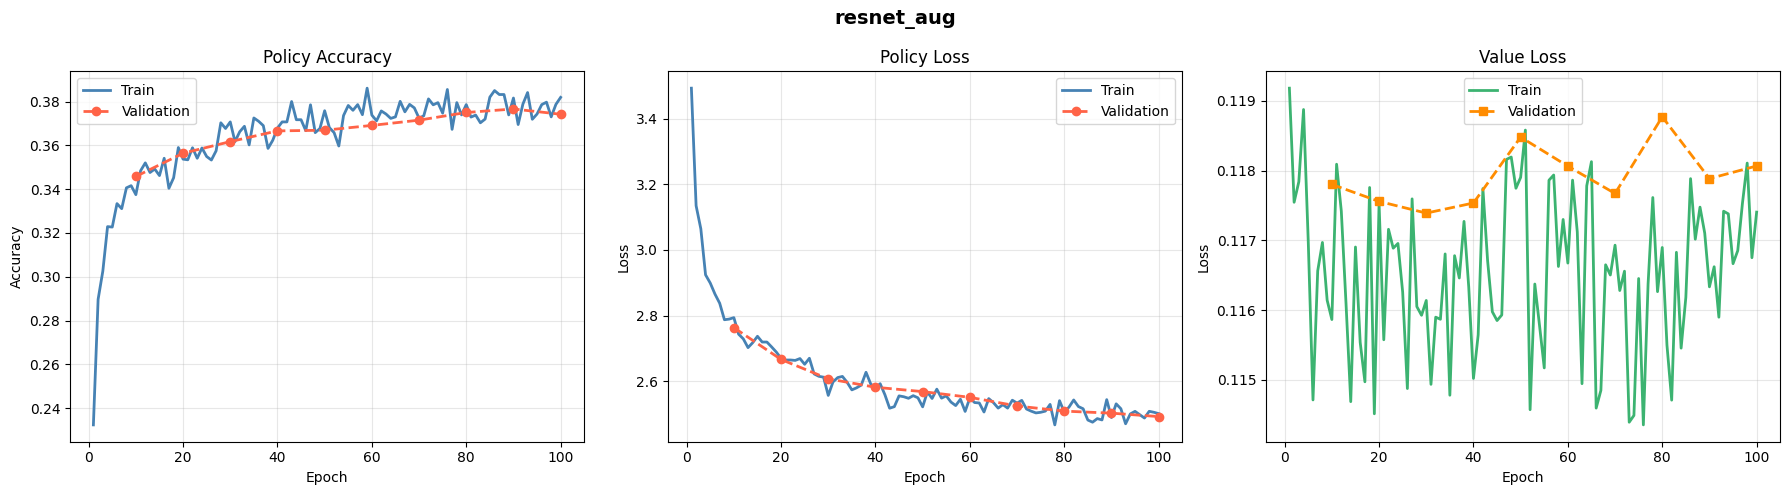

0.3765999972820282

In [ ]:
# ResNet - AVEC augmentation (×8 symétries)
model = resnet_model(filters=32, n_blocks=3)
entrainement_reseau(
    model, EPOCHS, BATCH_SIZE,
    input_data, policy, value, N, end, groups,
    val_every=VAL_EVERY, name_network="resnet_aug",
    augmentation=True
)


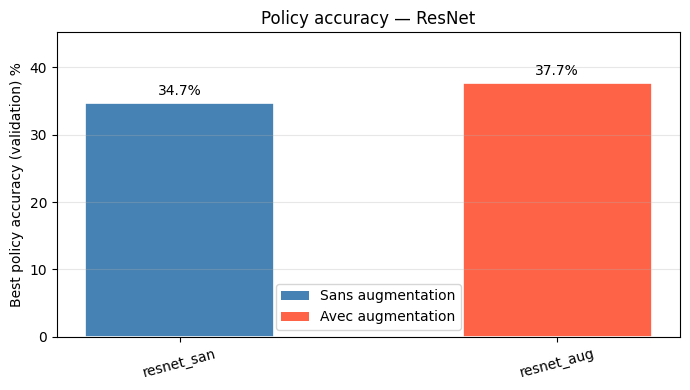

In [ ]:
# Comparaison ResNet
plot_barres_architecture(
    ["resnet_san", "resnet_aug"],
    label="Policy accuracy — ResNet"
)


## 6. Résumé final

Comparaison de toutes les architectures avec et sans augmentation.


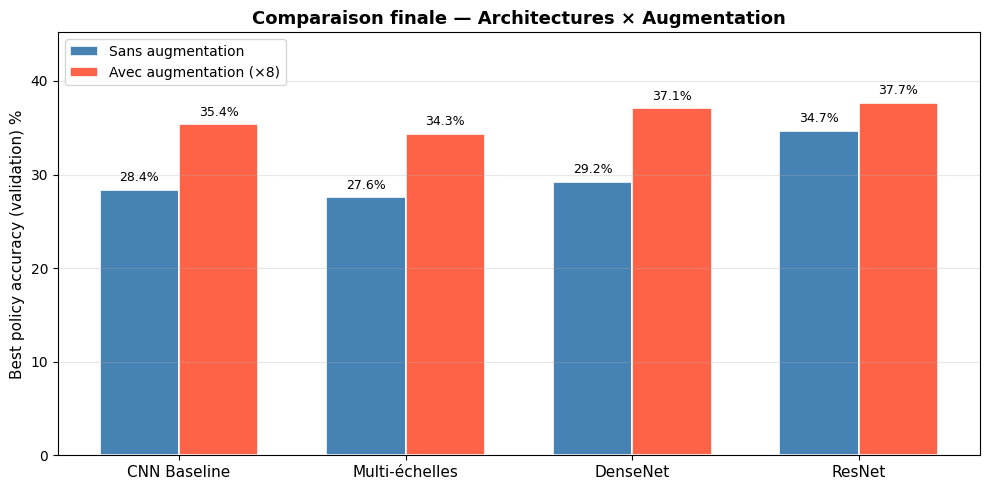


-- Meilleur modèle -----------------------------------------------
  resnet_aug → 37.66%


In [ ]:
plot_resume_final()


## 7. Évaluation des modèles sauvegardés

Charge les `.h5` et évalue sur plusieurs batches de données fraîches.


In [ ]:
def charger_model(path_modele):
    """Charge un modèle et le recompile."""
    model = keras.models.load_model(path_modele, compile=False)
    model.compile(
        optimizer=keras.optimizers.Adam(1e-4),
        loss={'policy': 'categorical_crossentropy', 'value': 'mse'},
        metrics={'policy': ['accuracy'], 'value': ['mae']}
    )
    return model

def evaluer_modele(model, N=10000, n_batches=10, batch_size=128):
    """Évalue un modèle sur n_batches batches. Retourne la policy_accuracy moyenne."""
    accs = []
    for i in range(n_batches):
        golois.getBatch(input_data, policy, value, end, groups, i * N)
        val = model.evaluate(input_data, {'policy': policy, 'value': value},
                             verbose=0, batch_size=batch_size, return_dict=True)
        accs.append(val['policy_accuracy'])
    mean_acc = np.mean(accs)
    print(f"Policy accuracy moyenne ({n_batches} batches) : {mean_acc*100:.2f}%")
    return mean_acc

def evaluer_tous(liste_modeles):
    """Évalue et affiche un résumé comparatif."""
    resultats = {}
    for path in liste_modeles:
        print(f"\n-- Évaluation : {path}")
        m = charger_model(path)
        acc = evaluer_modele(m)
        resultats[path] = acc
    print("\n-- Résumé -------------------------------------------------")
    for path, acc in sorted(resultats.items(), key=lambda x: -x[1]):
        print(f"  {acc*100:.2f}%  {path}")
    return resultats

modeles_a_tester = [
    "baseline_cnn_san.h5", "baseline_cnn_aug.h5",
    "multiscale_san.h5",   "multiscale_aug.h5",
    "densenet_san.h5",     "densenet_aug.h5",
    "resnet_san.h5",       "resnet_aug.h5",
]
resultats = evaluer_tous(modeles_a_tester)
